# FF3: Wettersensitivität des Zürcher Velonetz

---

<style>
table { border-collapse: collapse; width: 100%; font-size: 0.92em; }
th { background-color: #404040; color: white; padding: 8px 12px; text-align: left; font-weight: 600; }
td { padding: 7px 12px; border-bottom: 1px solid #e0e0e0; }
tr:nth-child(even) td { background-color: #f5f5f5; }
tr:hover td { background-color: #eaeaea; }
</style>

| Attribut | Beschreibung |
|---|---|
| **Forschungsfrage** | Wie stark reagiert das Veloaufkommen an einzelnen Zürcher Zählstellen auf Regen und tiefe Temperaturen im Vergleich zum Netzwerk-Durchschnitt, und welche Standorte weisen eine überdurchschnittliche Wettersensitivität auf? |
| **Datenquellen** | Open Data Stadt Zürich (3 Datensätze, vollautomatisiert) |
| **Analysezeitraum** | 2020–2025 |
| **Framework** | CPA Management Accounting Guideline – From Data to Decisions (Marr, 2020) |
| **Visualisierung** | IBCS-Standard (UN 3.2: AC=dunkelgrau, PY=hellgrau, FC=schraffiert) |
| **Vorhersage** | Multivariates OLS-Modell + Konfidenzband + Standort-Priorisierung |

---
## 0. Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotly fuer interaktive Visuals (Bewertungsraster: interaktive Datenvisualisierung)
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
    print('Plotly verfuegbar – interaktive Charts aktiv.')
except ImportError:
    PLOTLY_OK = False
    print('Plotly nicht installiert. Nur statische Charts.')

# ── IBCS-konforme Matplotlib-Grundeinstellungen (UN SUCCESS-Formel) ──────────
plt.rcParams.update({
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'axes.edgecolor':     '#404040',
    'axes.linewidth':     0.6,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'axes.axisbelow':     True,
    'grid.color':         '#E0E0E0',
    'grid.linewidth':     0.5,
    'grid.linestyle':     '-',
    'grid.alpha':         0.6,
    'xtick.color':        '#404040',
    'ytick.color':        '#404040',
    'xtick.major.size':   3,
    'ytick.major.size':   3,
    'xtick.major.width':  0.6,
    'ytick.major.width':  0.6,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'text.color':         '#1A1A1A',
    'font.family':        'sans-serif',
    'font.size':          10,
    'axes.titlesize':     10,
    'axes.titleweight':   'normal',
    'axes.titlecolor':    '#1A1A1A',
    'axes.titlepad':      8,
    'axes.labelsize':     9,
    'axes.labelcolor':    '#1A1A1A',
    'axes.labelpad':      6,
    'legend.fontsize':    8.5,
    'legend.frameon':     False,
    'lines.linewidth':    1.5,
    'patch.linewidth':    0.8,
    'figure.dpi':         120,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  'white',
})

# ── IBCS Szenario-Farben (UN 3.2) ───────────────────────────────────────────
# AC (Ist/Actual)   -> solid dunkelgrau  #404040
# PY (Vorjahr)      -> solid hellgrau    #A0A0A0
# PL (Plan)         -> outlined (Rahmen, kein Fill)
# FC (Forecast)     -> schraffiert (hatched)
IBCS = {
    'AC':       '#404040',
    'PY':       '#A0A0A0',
    'neutral':  '#C8C8C8',
    'positive': '#404040',
    'negative': '#A0A0A0',
    'ref_line': '#1A1A1A',
}

def ibcs_title(ax, kennzahl, einheit, einheit2=None, zeitraum=None):
    parts = [kennzahl + ' in ' + einheit]
    if einheit2: parts.append(einheit2)
    if zeitraum: parts.append(zeitraum)
    ax.set_title('  |  '.join(parts), loc='left', fontsize=9,
                 fontweight='normal', color='#1A1A1A', pad=6)

def ibcs_bar_label(ax, bars, vals, fmt='{:.0f}', offset=2, fs=8):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+offset,
                fmt.format(v), ha='center', va='bottom', fontsize=fs, color='#1A1A1A')

def ibcs_barh_label(ax, bars, vals, fs=8):
    for bar, v in zip(bars, vals):
        xpos = v - 0.4 if v < 0 else v + 0.4
        ha   = 'right' if v < 0 else 'left'
        c    = 'white' if abs(v) > 3 else '#1A1A1A'
        ax.text(xpos, bar.get_y()+bar.get_height()/2,
                f'{v:.1f}%', ha=ha, va='center', fontsize=fs, color=c)

print('IBCS-Setup abgeschlossen.')

Plotly nicht installiert. Nur statische Charts.
IBCS-Setup abgeschlossen.


##1 Einleitung
Die Stadt Zürich verfolgt mit der Velostrategie 2030 das Ziel, Velofahren „für alle jederzeit selbstverständlich“ zu machen. Eine zentrale Voraussetzung dafür ist eine Infrastruktur, die auch unter variierenden Wetterbedingungen zuverlässig genutzt wird.

Diese Arbeit untersucht, inwiefern das Veloaufkommen in Zürich wetterabhängig ist und welche Standorte besonders sensitiv auf Regen und Kälte reagieren.

Die Ergebnisse sollen eine evidenzbasierte Grundlage für die Priorisierung infrastruktureller Massnahmen liefern.

---
## 2 Definition der Ziele und Festlegung der Daten

### 2.1 Zielsetzung der Analyse

Ziel der vorliegenden Analyse ist es, die Wettersensitivität des Veloverkehrs in der Stadt Zürich systematisch zu untersuchen und damit einen Beitrag zur Bewertung der Alltagstauglichkeit der bestehenden Veloinfrastruktur zu leisten.

Ausgangspunkt bildet das strategische Ziel der Velostrategie 2030, wonach Velofahren in Zürich „für alle jederzeit selbstverständlich“ werden soll. Dieses Ziel impliziert eine möglichst geringe Abhängigkeit der Velonutzung von externen Einflussfaktoren wie Wetterbedingungen.

Zur strukturierten Beantwortung der Fragestellung werden vier Leitfragen definiert:

**L1**: Wie stark sinkt das Veloaufkommen im Netzwerk bei Regen im Vergleich zu trockenen Bedingungen?

**L2**: Wie stark sinkt das Veloaufkommen bei tiefen Temperaturen im Vergleich zu milden Bedingungen?

**L3**: Welche Zählstellen weichen überdurchschnittlich stark vom Netzwerk-Durchschnitt ab?

**L4**: Wie haben sich das Veloaufkommen sowie die Wettersensitivität im Zeitraum 2020–2025 entwickelt?
#
### 2.2 Forschungsfrage

**Wie stark reagiert das Veloaufkommen an einzelnen Zürcher Zählstellen auf Regen und tiefe Temperaturen im Vergleich zum Netzwerk-Durchschnitt, und welche Standorte weisen eine überdurchschnittliche Wettersensitivität auf?**
#
### 2.3 Definition der benötigten Daten

<style>
table { border-collapse: collapse; width: 100%; font-size: 0.91em; }
th { background-color: #404040; color: white; padding: 8px 12px; text-align: left; }
td { padding: 7px 12px; border-bottom: 1px solid #e0e0e0; }
tr:nth-child(even) td { background-color: #f5f5f5; }
</style>
#
| Datensatz | Variable | Funktion |
|---|---|---|
| Verkehrsdaten | VELO_IN, VELO_OUT, FK_STANDORT, DATUM | Zielvariable VELO_TOTAL |
| Wetterdaten | Temperatur (T), Niederschlagsdauer (RainDur) | Einflussvariablen |
| Standortdaten | id1, bezeichnung | Interpretation der Ergebnisse |
#
Auf Basis der Rohdaten werden folgende zentrale Analysevariablen gebildet:
#
- $VELO\_TOTAL = VELO\_IN + VELO\_OUT$ → Gesamtzahl der Velofahrten pro Standort und Tag
- **REGEN:** Niederschlagsdauer > 30 Minuten pro Tag
- **KALT:** Tagesmitteltemperatur ≤ 5°C
- **RÜCKGANG\_PCT:** Prozentualer Rückgang des Veloaufkommens bei schlechten Wetterbedingungen
- **ABWEICHUNG\_VOM\_NETZ\_PCT:** Differenz zwischen standortspezifischem Rückgang und Netzwerk-Durchschnitt

Die gewählten Variablen ermöglichen eine quantitative Analyse der Wetterabhängigkeit des Veloverkehrs sowie einen Vergleich zwischen einzelnen Standorten und dem Gesamtnetz.

---
## 3 Daten sammeln

### 3.1 Quellen

Für die Analyse werden drei zentrale Datensätze aus dem Open-Data-Portal der Stadt Zürich verwendet. Diese decken sowohl das Veloaufkommen als auch die relevanten Wetterbedingungen und Standortinformationen ab.

<style>
table { border-collapse: collapse; width: 100%; font-size: 0.91em; }
th { background-color: #404040; color: white; padding: 8px 12px; text-align: left; }
td { padding: 7px 12px; border-bottom: 1px solid #e0e0e0; }
tr:nth-child(even) td { background-color: #f5f5f5; }
</style>

| Datensatz | Quelle | Format | Zeitraum |
|---|---|---|---|
| Automatische Velozählungen | Open Data Stadt Zürich | Parquet | 2009–2025 |
| Meteodaten Stampfenbachstrasse | Open Data Stadt Zürich | CSV (Jahresdateien) | 2020–2026 |
| Standortdaten Velozähler | Open Data Stadt Zürich | CSV | ohne Zeitbezug |
#
### 3.1.1 Legenden
#
**Verkehrsdaten:**

| Variable | Beschreibung |
|---|---|
| FK_STANDORT | Eindeutige numerische ID der Zählstelle |
| DATUM | Zeitstempel der Messung im ISO-8601-Format |
| VELO_IN | Anzahl einfahrender Velos pro Messintervall |
| VELO_OUT | Anzahl ausfahrender Velos pro Messintervall |

**Meteodaten Messstation Stampfenbachstrasse:**

| Parameter | Einheit | Beschreibung |
|---|---|---|
| temp_mean | °C | Tagesmitteltemperatur in 2 m Höhe |
| rain_dur | min/Tag | Tägliche Niederschlagsdauer |

**Wetterklassifikation:**
#
Zur Analyse der Wettersensitivität werden die kontinuierlichen Wettervariablen in kategoriale Indikatoren überführt. Dies ermöglicht einen direkten Vergleich des Veloaufkommens unter unterschiedlichen Wetterbedingungen.
#
| Variable | Definition | Schwellenwert | Begründung |
|---|---|---|---|
| REGEN | Niederschlagsdauer > Schwelle | > 30 min/Tag | Signifikanter Niederschlag, der Komfort beeinflusst |
| KALT | Tagesmitteltemperatur ≤ Schwelle | ≤ 5.0°C | Komfort- und Sicherheitsschwelle; Glätterisiko steigt |

Die gewählten Schwellenwerte stellen analytische Vereinfachungen dar und dienen der Vergleichbarkeit der Effekte über alle Standorte hinweg.

Basierend auf diesen Indikatoren werden die Beobachtungen in vier disjunkte Wetterkategorien eingeteilt:

- **Trocken & mild** (Referenzkategorie)
- **Nur Regen**
- **Nur Kälte**
- **Regen & Kälte kombiniert**

### 3.2 Import, Bereinigung und Transformation

Im folgenden Schritt werden die relevanten Datensätze importiert, bereinigt und in eine analysierbare Struktur überführt. Ziel ist es, ein konsistentes, integriertes Datenset auf Tagesebene zu erstellen, welches sowohl Verkehrs- als auch Wetterinformationen pro Standort enthält.

Dieser Schritt entspricht der Datenaufbereitung im Sinne des DDDM-Prozesses und stellt die Grundlage für eine valide und vergleichbare Analyse dar.



####3.2.1 Daten importieren
Die Datensätze werden in das Analyseumfeld (Google Colab) geladen und mittels geeigneter Bibliotheken (pandas) eingelesen.

Die Verkehrsdaten liegen im Parquet-Format vor und können effizient direkt in einen DataFrame importiert werden. Die Meteodaten werden aus mehreren CSV-Dateien (je Jahr) eingelesen und anschliessend zu einem konsistenten Gesamtdatensatz zusammengeführt.

Die Standortdaten werden ebenfalls als CSV-Datei importiert und dienen zur Ergänzung der Zählstellenbezeichnungen im späteren Analyseprozess.

Durch die strukturierte Einlesung wird sichergestellt, dass alle Datenquellen in einem einheitlichen Format für die Verarbeitung zur Verfügung stehen.

Beim Import wird darauf geachtet, dass Datumsvariablen korrekt als Zeitstempel interpretiert und numerische Variablen in geeignete Datentypen konvertiert werden, um eine fehlerfreie Weiterverarbeitung sicherzustellen.

In [2]:
# Local-friendly replacement for the original Colab Drive mount:
# in Colab the original cell mounts /content/drive; locally we no-op and
# rely on the data being present at ../../data (downloaded by Notebook 01).
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass  # nicht in Colab - data/ wird lokal aus Notebook 01 versorgt.


In [3]:
pfad = "../../data"


In [4]:
import os

print(os.listdir(pfad))


['2020_verkehrszaehlungen_werte_fussgaenger_velo.csv', '2021_verkehrszaehlungen_werte_fussgaenger_velo.csv', '2022_verkehrszaehlungen_werte_fussgaenger_velo.csv', '2023_verkehrszaehlungen_werte_fussgaenger_velo.csv', '2024_verkehrszaehlungen_werte_fussgaenger_velo.csv', '2025_verkehrszaehlungen_werte_fussgaenger_velo.csv', 'basel_velo_fuss_count.csv', 'clean', 'meteo_sma_h_2020_2029.csv', 'meteo_sma_h_now.csv', 'sg_velo_daily.csv', 'standorte_velo_fuss.json', 'taz.view_eco_standorte.csv', 'ugz_ogd_meteo_d1_2020.csv', 'ugz_ogd_meteo_d1_2021.csv', 'ugz_ogd_meteo_d1_2022.csv', 'ugz_ogd_meteo_d1_2023.csv', 'ugz_ogd_meteo_d1_2024.csv', 'ugz_ogd_meteo_d1_2025.csv', 'verkehrszaehlungen_werte_fussgaenger_velo_alle_jahre.parquet']


In [5]:
# Dateinamen
VERKEHR_PARQUET = '../../data/verkehrszaehlungen_werte_fussgaenger_velo_alle_jahre.parquet'
STANDORTE_CSV   = '../../data/taz.view_eco_standorte.csv'
METEO_DATEIEN   = [
    'ugz_ogd_meteo_d1_2020.csv',
    'ugz_ogd_meteo_d1_2021.csv',
    'ugz_ogd_meteo_d1_2022.csv',
    'ugz_ogd_meteo_d1_2023.csv',
    'ugz_ogd_meteo_d1_2024.csv',
    'ugz_ogd_meteo_d1_2025.csv',

]
ANALYSE_JAHRE = range(2020, 2026)
print('Konfiguration gesetzt.')


Konfiguration gesetzt.


#### 3.2.2 Daten bereinigen

Die Rohdaten werden bereinigt, um eine konsistente und zuverlässige Grundlage für die Analyse zu schaffen. Ziel der Bereinigung ist es, fehlerhafte, unvollständige oder nicht interpretierbare Beobachtungen zu entfernen sowie einheitliche Datenformate sicherzustellen.

Folgende Bereinigungsschritte werden durchgeführt:

- **Entfernung von technischen Artefakten:**  
  In den Spaltenbezeichnungen enthaltene BOM-Zeichen (\ufeff) werden entfernt, um eine korrekte Weiterverarbeitung der Daten zu gewährleisten.

- **Ausschluss unvollständiger Beobachtungen:**  
  Beobachtungen ohne Velodaten (d. h. VELO_IN und VELO_OUT beide fehlend) werden ausgeschlossen, da für diese keine Aussage zum Veloaufkommen möglich ist.

- **Standardisierung von Zeitvariablen:**  
  Datumsspalten werden in ein einheitliches datetime-Format konvertiert, um eine korrekte zeitliche Aggregation und Verknüpfung mit Wetterdaten zu ermöglichen.

- **Konvertierung numerischer Variablen:**  
  Messwerte werden in numerische Datentypen überführt. Nicht interpretierbare Einträge werden als fehlende Werte behandelt, um Verzerrungen in der Analyse zu vermeiden.

- **Einschränkung des Analysezeitraums:**  
  Die Daten werden auf den Zeitraum 2020–2025 gefiltert, da für diesen Zeitraum sowohl konsistente Verkehrsdaten als auch vollständige Meteodaten vorliegen.


**Meteodaten laden und bereinigen:**


In [6]:
from IPython.display import display, HTML
import os

dfs = []
rows = []
for datei in METEO_DATEIEN:
    try:
        #Pfad zum File
        full_path = os.path.join(pfad, datei)
        df = pd.read_csv(full_path, sep=None, engine='python')
        df.columns = df.columns.str.strip().str.replace('"','').str.replace('\ufeff','')
        dfs.append(df)
        rows.append(f"<tr><td>✅</td><td>{datei}</td><td>{len(df):,}</td></tr>")
    except FileNotFoundError:
        rows.append(f"<tr style='color:#cc0000'><td>❌</td><td>{datei}</td><td>–</td></tr>")
    except Exception as e:
        rows.append(f"<tr style='color:#cc0000'><td>❌</td><td>{datei}</td><td>Error: {e}</td></tr>")

# Check ob dfs lehr sind vor dem concat
if not dfs:
    print("No meteo data files were loaded successfully.")
    # Initialisierung leerer df mit den erwarteten Spalten, um weitere Fehler zu vermeiden
    df_m = pd.DataFrame(columns=['Datum', 'Standort', 'Parameter', 'Wert'])
else:
    df_m = pd.concat(dfs, ignore_index=True)


if not df_m.empty:
    df_m['Datum']     = pd.to_datetime(df_m['Datum'], utc=True, errors='coerce')
    df_m              = df_m.dropna(subset=['Datum'])
    df_m['DATUM_TAG'] = df_m['Datum'].dt.date
    df_m['Wert']      = pd.to_numeric(df_m['Wert'], errors='coerce')

    df_stamp = df_m[df_m['Standort'] == 'Zch_Stampfenbachstrasse']
    wetter   = df_stamp.pivot_table(index='DATUM_TAG', columns='Parameter',
                                     values='Wert', aggfunc='mean').reset_index()
    wetter.columns.name = None
    wetter = wetter.rename(columns={'T': 'temp_mean', 'RainDur': 'rain_dur'})
    wetter['DATUM_TAG'] = pd.to_datetime(wetter['DATUM_TAG'])
    wetter = wetter[wetter['DATUM_TAG'].dt.year.isin(ANALYSE_JAHRE)]

    display(HTML(f"""
    <div style="font-family:Arial;font-size:12px;max-width:560px">
      <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
        METEODATEN  |  Stampfenbachstrasse  |  {min(ANALYSE_JAHRE)}–{max(ANALYSE_JAHRE)}
      </div>
      <table style="width:100%;border-collapse:collapse;font-size:11px">
        <tr style="background:#f0f0f0;color:#555">
          <th style="padding:5px 10px;text-align:left"></th>
          <th style="padding:5px 10px;text-align:left">Datei</th>
          <th style="padding:5px 10px;text-align:right">Zeilen</th>
        </tr>
        {''.join(rows)}
      </table>
      <div style="display:flex;gap:6px;margin-top:8px">
        <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #404040">
          <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Tage gesamt</div>
          <div style="font-size:20px;font-weight:700;color:#1a1a1a">{len(wetter):,}</div>
        </div>
        <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #a0a0a0">
          <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Zeitraum</div>
          <div style="font-size:12px;font-weight:600;color:#1a1a1a;margin-top:3px">
            {wetter['DATUM_TAG'].min().strftime('%d.%m.%Y')} – {wetter['DATUM_TAG'].max().strftime('%d.%m.%Y')}
          </div>
        </div>
        <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #c8c8c8">
          <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Ø Temperatur</div>
          <div style="font-size:20px;font-weight:700;color:#1a1a1a">{wetter['temp_mean'].mean():.1f} °C</div>
        </div>
      </div>
    </div>
    """))
else:
    display(HTML(f"""
    <div style="font-family:Arial;font-size:12px;max-width:560px">
      <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
        METEODATEN  |  Stampfenbachstrasse  |  {min(ANALYSE_JAHRE)}–{max(ANALYSE_JAHRE)}
      </div>
      <table style="width:100%;border-collapse:collapse;font-size:11px">
        <tr style="background:#f0f0f0;color:#555">
          <th style="padding:5px 10px;text-align:left"></th>
          <th style="padding:5px 10px;text-align:left">Datei</th>
          <th style="padding:5px 10px;text-align:right">Zeilen</th>
        </tr>
        {''.join(rows)}
      </table>
      <div style="color:#cc0000; margin-top: 10px;">Error: No meteo data could be loaded. Please check file paths and availability.</div>
    </div>
    """))

,Datei,Zeilen
✅,ugz_ogd_meteo_d1_2020.csv,"4,758"
✅,ugz_ogd_meteo_d1_2021.csv,"4,745"
✅,ugz_ogd_meteo_d1_2022.csv,"4,745"
✅,ugz_ogd_meteo_d1_2023.csv,"4,745"
✅,ugz_ogd_meteo_d1_2024.csv,"5,856"
✅,ugz_ogd_meteo_d1_2025.csv,"5,840"


Die Meteodaten wurden nun erfolgreich geladen.

**Verkehrsdaten laden und aggregieren:**

Die Verkehrsdaten werden aus einer Parquet-Datei eingelesen. Der ursprüngliche Datensatz umfasst rund 15.38 Millionen Beobachtungen für den Zeitraum 2009 bis 2025 und liegt auf Intervallbasis vor.

Für die vorliegende Analyse wird der Datensatz auf den Untersuchungszeitraum 2020 bis 2025 eingeschränkt. Anschliessend werden Beobachtungen ausgeschlossen, bei denen sowohl `VELO_IN` als auch `VELO_OUT` fehlen, da in diesen Fällen keine Aussage über das Veloaufkommen möglich ist.

Die Variablen `VELO_IN` und `VELO_OUT` werden in numerische Datentypen konvertiert. Nicht interpretierbare Werte werden als fehlend behandelt und anschliessend mit 0 ersetzt, um die Berechnung des gesamten Veloaufkommens pro Messintervall zu ermöglichen.

Da die Forschungsfrage auf die Reaktion des täglichen Veloaufkommens auf Wetterbedingungen abzielt, werden die Zeitstempel auf Tagesebene normalisiert und die Intervallwerte pro Standort und Kalendertag aggregiert.

Nach der Filterung auf den Analysezeitraum und der Aggregation reduziert sich der Datensatz von 15.38 Millionen Zeilen auf 46'886 Standort-Tag-Kombinationen. Diese bilden die Grundlage für die anschliessende Verknüpfung mit den Wetterdaten.

In [7]:
from IPython.display import display, HTML

df_raw = pd.read_parquet(VERKEHR_PARQUET)
n_gesamt = len(df_raw)
spalten  = df_raw.columns.tolist()

df_raw['DATUM']      = pd.to_datetime(df_raw['DATUM'], errors='coerce')
df_raw               = df_raw[df_raw['DATUM'].dt.year.isin(ANALYSE_JAHRE)]
df_raw               = df_raw.dropna(subset=['VELO_IN','VELO_OUT'], how='all')
df_raw['VELO_IN']    = pd.to_numeric(df_raw['VELO_IN'],  errors='coerce').fillna(0)
df_raw['VELO_OUT']   = pd.to_numeric(df_raw['VELO_OUT'], errors='coerce').fillna(0)
df_raw['VELO_TOTAL'] = df_raw['VELO_IN'] + df_raw['VELO_OUT']
df_raw['DATUM_TAG']  = df_raw['DATUM'].dt.normalize()

velo = df_raw.groupby(['FK_STANDORT','DATUM_TAG'], as_index=False)['VELO_TOTAL'].sum()

display(HTML(f"""
<div style="font-family:Arial;font-size:12px;max-width:560px">
  <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
    VERKEHRSDATEN  |  {min(ANALYSE_JAHRE)}–{max(ANALYSE_JAHRE)}
  </div>
  <div style="display:flex;gap:6px;margin-top:8px">
    <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #404040">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Rohdaten gesamt</div>
      <div style="font-size:20px;font-weight:700;color:#1a1a1a">{n_gesamt:,}</div>
      <div style="font-size:9px;color:#aaa">Zeilen</div>
    </div>
    <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #a0a0a0">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Nach Aggregation</div>
      <div style="font-size:20px;font-weight:700;color:#1a1a1a">{len(velo):,}</div>
      <div style="font-size:9px;color:#aaa">Standort-Tag-Kombis</div>
    </div>
    <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #c8c8c8">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Standorte</div>
      <div style="font-size:20px;font-weight:700;color:#1a1a1a">{velo['FK_STANDORT'].nunique()}</div>
      <div style="font-size:9px;color:#aaa">Zählstellen</div>
    </div>
  </div>
  <div style="margin-top:6px;background:#fafafa;padding:6px 12px;border:1px solid #e8e8e8;font-size:10px;color:#555">
    <b>Spalten:</b> {', '.join(spalten)}
  </div>
</div>
"""))

Die Verkehrsdaten wurden nun erfolgreich geladen und aggregiert.

**Standortdaten laden:**

Die Standortdaten werden aus einer CSV-Datei eingelesen und für die weitere Analyse vorbereitet.

Zunächst werden mögliche technische Artefakte in den Spaltenbezeichnungen (z. B. BOM-Zeichen) entfernt, um eine konsistente Weiterverarbeitung sicherzustellen.

Anschliessend wird geprüft, ob im Datensatz eine Variable vorhanden ist, die explizit Velozählstellen kennzeichnet. Falls eine solche Variable existiert, werden nur jene Standorte berücksichtigt, bei denen eine Velomessung erfolgt.

Die relevanten Informationen (Standort-ID und Bezeichnung) werden extrahiert und auf eindeutige Standorte reduziert, um Mehrfachnennungen zu vermeiden.

Das resultierende Datenset enthält somit eine bereinigte und deduplizierte Liste aller für die Analyse relevanten Velozählstellen.


In [8]:
from IPython.display import display, HTML

df_st = pd.read_csv(STANDORTE_CSV, sep=None, engine='python')
df_st.columns = df_st.columns.str.lstrip('\ufeff')

# Nur Standorte die auch in den Verkehrsdaten vorkommen → garantiert korrekte Anzahl
bekannte_ids = velo['FK_STANDORT'].unique()
standorte = (df_st[df_st['id1'].isin(bekannte_ids)][['id1','bezeichnung']]
               .drop_duplicates('id1'))

preview_rows = ''.join(
    "<tr style='border-bottom:1px solid #e8e8e8'>"
    "<td style='padding:4px 10px;color:#888'>" + str(row.id1) + "</td>"
    "<td style='padding:4px 10px'>" + str(row.bezeichnung) + "</td></tr>"
    for row in standorte.head(8).itertuples()
)

display(HTML(
    "<div style='font-family:Arial;font-size:12px;max-width:420px'>"
    "<div style='background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em'>"
    "STANDORTDATEN  |  Velozaehlstellen"
    "</div>"
    "<div style='background:#f7f7f7;padding:8px 12px;border-left:3px solid #404040;margin-top:8px'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>Velo-Standorte gesamt</div>"
    "<div style='font-size:20px;font-weight:700;color:#1a1a1a'>" + str(len(standorte)) + "</div>"
    "</div>"
    "<table style='width:100%;border-collapse:collapse;font-size:11px;margin-top:8px'>"
    "<tr style='background:#f0f0f0;color:#555'>"
    "<th style='padding:5px 10px;text-align:left'>ID</th>"
    "<th style='padding:5px 10px;text-align:left'>Bezeichnung</th>"
    "</tr>"
    + preview_rows +
    "<tr><td colspan='2' style='padding:4px 10px;font-size:10px;color:#aaa'>"
    "... " + str(len(standorte)-8) + " weitere Standorte</td></tr>"
    "</table>"
    "</div>"
))

Die Standortdaten wurden nun erfolgreich geladen und verarbeitet.

#### 3.2.3 Umgang mit fehlenden Daten

Im Datensatz treten fehlende Werte in zwei zentralen Kontexten auf: bei Verkehrsdaten (z. B. aufgrund von Geräteausfällen) sowie bei der Klassifikation von Wetterkategorien auf Standortebene.

Ein wesentliches Problem ergibt sich daraus, dass nicht für alle Standorte ausreichend Beobachtungen in jeder Wetterkategorie vorliegen. Insbesondere seltene Kombinationen wie kalte Tage oder die gleichzeitige Auftretung von Regen und Kälte können dazu führen, dass für einzelne Standorte keine stabilen Durchschnittswerte berechnet werden können.

In solchen Fällen werden die entsprechenden Kennzahlen mit `NaN` (Not a Number) markiert und automatisch aus aggregierten Berechnungen ausgeschlossen. Dadurch wird verhindert, dass unzureichend fundierte Werte die Analyse verzerren.

Eine Interpolation fehlender Werte wird bewusst nicht vorgenommen, da es sich nicht um zufällige Lücken, sondern um strukturell fehlende Beobachtungen handelt (z. B. fehlende Wetterkonstellationen). Zudem liefert die Aggregation auf Tagesebene eine ausreichend grosse Anzahl valider Beobachtungen für die meisten Standorte.

Die Behandlung fehlender Daten stellt somit einen Kompromiss zwischen Datenverfügbarkeit und methodischer Robustheit dar und wird als Limitation der Analyse berücksichtigt.


#### 3.2.4 Operationalisierung der Wettersensitivität

Zur Analyse der Wettersensitivität werden die aufbereiteten Verkehrs-, Wetter- und Standortdaten zunächst in einem integrierten Analysedatensatz zusammengeführt. Die Verknüpfung erfolgt über das Datum sowie die Standort-ID, sodass für jede Standort-Tag-Kombination sowohl das Veloaufkommen als auch die entsprechenden Wetterbedingungen vorliegen.

Zusätzlich werden zeitliche Variablen abgeleitet (Jahr, Monat, Wochentag, Wochenend-Indikator), um eine spätere Analyse zeitlicher Effekte zu ermöglichen.

Zur eigentlichen Operationalisierung der Wettersensitivität werden zwei binäre Klassifikationsvariablen definiert:

- **REGEN:** Niederschlagsdauer > 30 Minuten pro Tag  
- **KALT:** Tagesmitteltemperatur ≤ 5.0 °C  

Die Schwellenwerte basieren auf praxisnahen Komfort- und Sicherheitsüberlegungen. Während längere Niederschlagsperioden den Fahrkomfort deutlich reduzieren, stellen tiefe Temperaturen insbesondere aufgrund von Kälteempfinden und möglicher Glätte eine stärkere Nutzungshürde dar.

Auf Basis dieser beiden Indikatoren werden die Beobachtungen in vier disjunkte Wetterkategorien eingeteilt:

- **Trocken & mild (KEINES)** – Referenzkategorie  
- **Nur Regen**  
- **Nur Kälte**  
- **Regen & Kälte kombiniert (BEIDE)**  

Die Referenzkategorie „trocken & mild“ dient als Vergleichsbasis für die Berechnung der relativen Veränderungen des Veloaufkommens.

Der resultierende Analysedatensatz umfasst 46'796 Standort-Tag-Kombinationen über 46 Zählstellen im Zeitraum von 2020 bis 2025.

Auf Tagesebene ergibt sich folgende Verteilung der Wetterbedingungen:

- **Regentage (>30 min):** 992 Tage (45.3 %)  
- **Kalte Tage (≤5 °C):** 397 Tage (18.1 %)  

Diese Verteilung zeigt, dass Regen vergleichsweise häufig auftritt, während kalte Tage deutlich seltener sind. Dies ist bei der Interpretation der späteren Analysen zu berücksichtigen, da Unterschiede in der Fallzahl die Stabilität der Ergebnisse beeinflussen können.

In [9]:
from IPython.display import display, HTML

# Merge: Velo + Wetter + Standortname
velo['DATUM_TAG'] = pd.to_datetime(velo['DATUM_TAG'])
df = velo.merge(wetter, on='DATUM_TAG', how='inner')
df = df.merge(standorte, left_on='FK_STANDORT', right_on='id1', how='left')

# Zeitvariablen
df['JAHR']       = df['DATUM_TAG'].dt.year
df['MONAT']      = df['DATUM_TAG'].dt.month
df['WOCHENTAG']  = df['DATUM_TAG'].dt.dayofweek
df['WOCHENENDE'] = df['WOCHENTAG'] >= 5

# Wetterklassifikation
REGEN_SCHWELLE = 30
KALT_SCHWELLE  = 5.0
df['REGEN']  = df['rain_dur'] > REGEN_SCHWELLE
df['KALT']   = df['temp_mean'] <= KALT_SCHWELLE
df['BEIDE']  = df['REGEN'] & df['KALT']
df['KEINES'] = ~df['REGEN'] & ~df['KALT']

n_tage   = wetter['DATUM_TAG'].nunique()
n_regen  = (wetter['rain_dur'] > REGEN_SCHWELLE).sum()
n_kalt   = (wetter['temp_mean'] <= KALT_SCHWELLE).sum()
n_beide  = ((wetter['rain_dur'] > REGEN_SCHWELLE) & (wetter['temp_mean'] <= KALT_SCHWELLE)).sum()
n_keines = ((wetter['rain_dur'] <= REGEN_SCHWELLE) & (wetter['temp_mean'] > KALT_SCHWELLE)).sum()
pct      = lambda n: f"{n/n_tage*100:.1f}%"

kacheln = [
    ('#404040', 'Analysedatensatz', f"{len(df):,}",                          'Zeilen'),
    ('#606060', 'Standorte',        str(df['FK_STANDORT'].nunique()),         'Zählstellen'),
    ('#808080', 'Zeitraum von',     df['DATUM_TAG'].min().strftime('%d.%m.%Y'), ''),
    ('#a0a0a0', 'Zeitraum bis',     df['DATUM_TAG'].max().strftime('%d.%m.%Y'), ''),
]

kat_rows = [
    ('Regen',   f'Regentage (>{REGEN_SCHWELLE} min)',      n_regen,  pct(n_regen)),
    ('Kälte',  f'Kalte Tage (max. {KALT_SCHWELLE} Grad)', n_kalt,   pct(n_kalt)),
    ('Kombi',   'Regen & Kälte kombiniert',               n_beide,  pct(n_beide)),
    ('Referenz','Trocken & mild (Referenz)',                n_keines, pct(n_keines)),
]

rows_html = ''.join(
    f"<tr style='border-bottom:1px solid #e8e8e8'>"
    f"<td style='padding:5px 10px;color:#888'>{k}</td>"
    f"<td style='padding:5px 10px'>{lab}</td>"
    f"<td style='padding:5px 10px;text-align:right;font-weight:600'>{n}</td>"
    f"<td style='padding:5px 10px;text-align:right;color:#888'>{p}</td></tr>"
    for k, lab, n, p in kat_rows
)

kacheln_html = ''.join(
    f"<div style='flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid {c}'>"
    f"<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>{t}</div>"
    f"<div style='font-size:18px;font-weight:700;color:#1a1a1a'>{v}</div>"
    f"<div style='font-size:9px;color:#aaa'>{s}</div></div>"
    for c, t, v, s in kacheln
)

display(HTML(f"""
<div style="font-family:Arial;font-size:12px;max-width:560px">
  <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
    ANALYSEDATENSATZ  |  Merge Velo + Wetter + Standorte
  </div>
  <div style="display:flex;gap:6px;margin-top:8px">{kacheln_html}</div>
  <div style="margin-top:10px;font-size:11px;color:#404040;font-weight:600;padding:5px 10px;background:#f0f0f0">
    Wetterkategorien  |  {n_tage} Tage total
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:11px">
    <tr style="background:#f0f0f0;color:#555;font-size:10px">
      <th style="padding:5px 10px;text-align:left">Kategorie</th>
      <th style="padding:5px 10px;text-align:left">Beschreibung</th>
      <th style="padding:5px 10px;text-align:right">Tage</th>
      <th style="padding:5px 10px;text-align:right">Anteil</th>
    </tr>
    {rows_html}
  </table>
</div>
"""))

Kategorie,Beschreibung,Tage,Anteil
Regen,Regentage (>30 min),992,45.3%
Kälte,Kalte Tage (max. 5.0 Grad),397,18.1%
Kombi,Regen & Kälte kombiniert,141,6.4%
Referenz,Trocken & mild (Referenz),930,42.5%


Alle Daten wurden erfolgreich zusammengeführt und die Wettersensitivität operationalisiert.

---
## 4 Daten analysieren
#
Die Analyse der Wettersensitivität des Veloverkehrs erfolgt in vier aufeinander aufbauenden Schritten. Ziel ist es, sowohl allgemeine Effekte auf Netzwerkebene als auch standortspezifische Unterschiede und zeitliche Entwicklungen zu identifizieren.
#
Die Analyse gliedert sich wie folgt:
#
1. **Deskriptive Übersicht:**  
   Grundlegende Charakterisierung des Datensatzes und des Veloaufkommens
#
2. **Analyse auf Netzwerkebene (L1, L2):**  
   Untersuchung des durchschnittlichen Einflusses von Regen und Kälte auf das Veloaufkommen
#
3. **Analyse auf Standortebene (L3):**  
   Identifikation von Standorten mit über- oder unterdurchschnittlicher Wettersensitivität
#
4. **Zeitliche Entwicklung (L4):**  
   Analyse der Entwicklung der Wettersensitivität im Zeitraum 2020–2025
#



###4.1 Deskriptive Übersicht
Der integrierte Analysedatensatz umfasst 46'796 Standort-Tag-Kombinationen und deckt 46 Zählstellen im Stadtgebiet Zürich ab.

Die Verteilung des Veloaufkommens weist eine ausgeprägte Rechtsschiefe auf. Während die Mehrheit der Standorte moderate Verkehrsvolumina zeigt, existieren einzelne hochfrequentierte Zählstellen mit deutlich höheren Werten.

Diese Heterogenität deutet darauf hin, dass das Velonetz unterschiedlich stark genutzt wird und einzelne Standorte eine überproportionale Bedeutung für das Gesamtaufkommen haben. Für die anschliessende Analyse bedeutet dies, dass sowohl absolute Werte als auch relative Veränderungen (z. B. prozentuale Rückgänge) berücksichtigt werden müssen, um vergleichbare Aussagen treffen zu können.

Die deskriptive Analyse bildet somit die Grundlage für die Interpretation der wetterbedingten Effekte auf Netzwerk- und Standortebene.



In [10]:
from IPython.display import display, HTML

def stat_block(series, label, einheit):
    d = series.describe().round(2)
    return (
        f"<div style='flex:1;background:#f7f7f7;padding:10px 14px;border-left:3px solid #404040'>"
        f"<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em;margin-bottom:6px'>{label}</div>"
        f"<table style='width:100%;border-collapse:collapse;font-size:11px'>"
        + ''.join(
            f"<tr style='border-bottom:1px solid #e8e8e8'>"
            f"<td style='padding:3px 6px;color:#888'>{k}</td>"
            f"<td style='padding:3px 6px;text-align:right;font-weight:600;color:#1a1a1a'>{v:,.2f} {einheit}</td></tr>"
            for k, v in d.items()
        )
        + "</table></div>"
    )

display(HTML(f"""
<div style="font-family:Arial;font-size:12px;max-width:760px">
  <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
    DESKRIPTIVE STATISTIK  |  Analysedatensatz 2020–2025
  </div>
  <div style="display:flex;gap:8px;margin-top:8px">
    {stat_block(df['VELO_TOTAL'], 'Veloaufkommen pro Standort-Tag', 'Fahr.')}
    {stat_block(df['temp_mean'],  'Tagesmitteltemperatur',          '°C')}
    {stat_block(df['rain_dur'],   'Niederschlagsdauer',             'min')}
  </div>
</div>
"""))

count,"46,533.00 Fahr."
mean,"1,438.55 Fahr."
std,"1,167.81 Fahr."
min,0.00 Fahr.
25%,630.00 Fahr.
50%,"1,111.00 Fahr."
75%,"1,894.00 Fahr."
max,"9,947.00 Fahr."
count,"46,283.00 °C"
mean,12.49 °C
std,7.40 °C


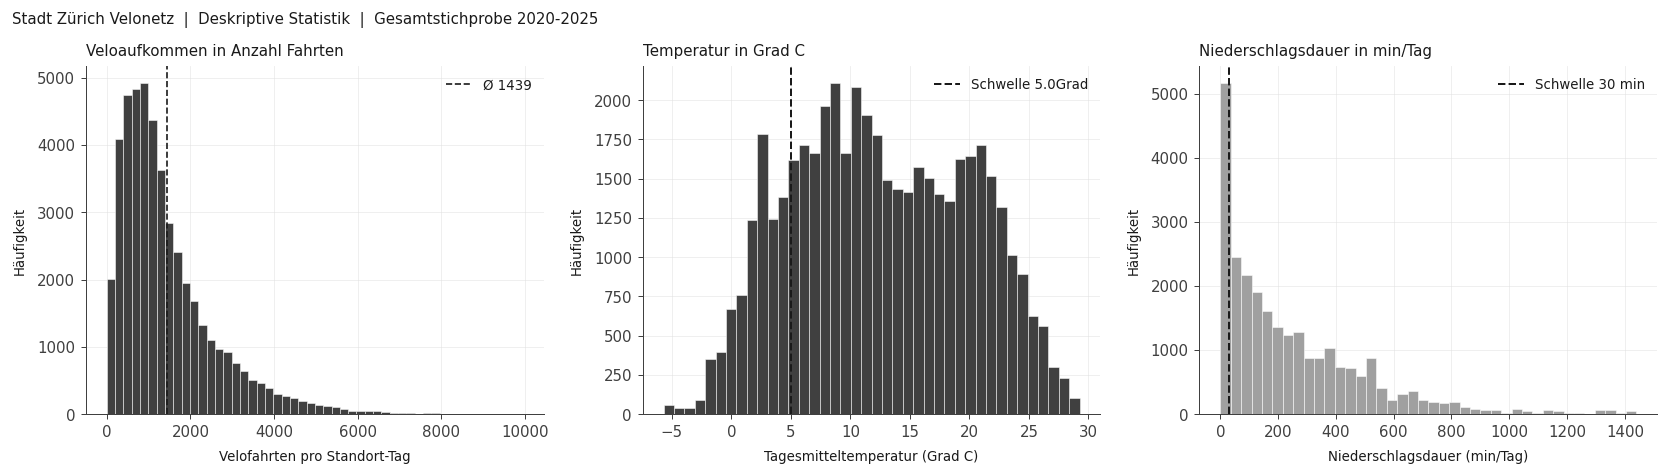

In [11]:
# Abb. 2-4: Deskriptive Verteilungen
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.text(0.01, 0.98, 'Stadt Zürich Velonetz  |  Deskriptive Statistik  |  Gesamtstichprobe 2020-2025',
         fontsize=9, va='top', color='#1A1A1A')

axes[0].hist(df['VELO_TOTAL'], bins=50, color=IBCS['AC'], edgecolor='white', linewidth=0.3)
axes[0].axvline(df['VELO_TOTAL'].mean(), color=IBCS['ref_line'], linestyle='--',
                linewidth=1, label=f'Ø {df["VELO_TOTAL"].mean():.0f}')
axes[0].set_xlabel('Velofahrten pro Standort-Tag', fontsize=8)
axes[0].set_ylabel('Häufigkeit', fontsize=8)
ibcs_title(axes[0], 'Veloaufkommen', 'Anzahl Fahrten')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(df['temp_mean'].dropna(), bins=40, color=IBCS['AC'], edgecolor='white', linewidth=0.3)
axes[1].axvline(x=KALT_SCHWELLE, color=IBCS['ref_line'], linestyle='--',
                linewidth=1.2, label=f'Schwelle {KALT_SCHWELLE}Grad')
axes[1].set_xlabel('Tagesmitteltemperatur (Grad C)', fontsize=8)
axes[1].set_ylabel('Häufigkeit', fontsize=8)
ibcs_title(axes[1], 'Temperatur', 'Grad C')
axes[1].legend(frameon=False, fontsize=8)

axes[2].hist(df[df['rain_dur']>0]['rain_dur'], bins=40, color=IBCS['PY'],
             edgecolor='white', linewidth=0.3)
axes[2].axvline(x=REGEN_SCHWELLE, color=IBCS['ref_line'], linestyle='--',
                linewidth=1.2, label=f'Schwelle {REGEN_SCHWELLE} min')
axes[2].set_xlabel('Niederschlagsdauer (min/Tag)', fontsize=8)
axes[2].set_ylabel('Häufigkeit', fontsize=8)
ibcs_title(axes[2], 'Niederschlagsdauer', 'min/Tag')
axes[2].legend(frameon=False, fontsize=8)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('abb_deskriptiv.png', dpi=150, bbox_inches='tight')
plt.show()

Die drei Histogramme zeigen die Verteilung zentraler Variablen des Analysedatensatzes. Die y-Achse stellt jeweils die absolute Häufigkeit dar, d. h. die Anzahl der Beobachtungen (Standort-Tag-Kombinationen), die in einen bestimmten Wertebereich fallen.

####4.1.2 Abbildungsbeschrieb
**Abbildung 2 (Veloaufkommen)** zeigt eine deutlich rechtsschiefe Verteilung. Die Mehrheit der Beobachtungen weist ein moderates Veloaufkommen auf, während sehr hohe Werte nur selten auftreten. Dies deutet darauf hin, dass wenige stark frequentierte Standorte das obere Ende der Verteilung dominieren, während der Grossteil des Netzes durch mittlere Verkehrsvolumina geprägt ist. Für die weitere Analyse bedeutet dies, dass relative Kennzahlen (z. B. prozentuale Veränderungen) gegenüber absoluten Werten zu bevorzugen sind, um eine verzerrungsfreie Vergleichbarkeit zwischen Standorten zu gewährleisten.
#
**Abbildung 3 (Temperatur)** zeigt eine breite, annähernd glockenförmige Verteilung mit einem Schwerpunkt im Bereich zwischen etwa 5 °C und 20 °C. Die definierte Kälteschwelle von 5 °C liegt im unteren Bereich der Verteilung und trennt die weniger häufigen kalten Tage klar von den dominierenden milden Bedingungen. Die gewählte Klassifikation ist somit sowohl datenbasiert als auch inhaltlich plausibel.
#
**Abbildung 4 (Niederschlagsdauer)** weist ebenfalls eine rechtsschiefe Verteilung auf. Der Grossteil der Tage ist durch geringe oder keine Niederschlagsdauer geprägt, während längere Regenperioden vergleichsweise selten auftreten. Die gewählte Schwelle von 30 Minuten liegt im unteren Bereich der positiven Niederschlagswerte und grenzt Tage mit relevantem Niederschlag klar von solchen mit nur kurzen oder unbedeutenden Regenereignissen ab.
#
Insgesamt bestätigen die Verteilungen, dass die gewählten Schwellenwerte für Kälte (≤ 5 °C) und Niederschlag (> 30 Minuten) sowohl datenlogisch als auch inhaltlich konsistent sind und eine sinnvolle Differenzierung der Wetterbedingungen ermöglichen. Gleichzeitig bilden sie eine geeignete Grundlage für die anschliessende Analyse der Wettersensitivität.
#
Die beobachteten Verteilungen unterstreichen zudem, dass extreme Wetterereignisse vergleichsweise selten sind, was bei der Interpretation standortspezifischer Effekte berücksichtigt werden muss.

### 4.2 Einfluss von Regen und Kälte auf das Veloaufkommen im Gesamtnetz (L1, L2)

Auf Netzwerkebene zeigt sich, dass sowohl Regen als auch tiefe Temperaturen mit einer deutlichen Reduktion des Veloaufkommens verbunden sind.

Wird zwischen Regentagen und Tagen ohne Regen unterschieden, sinkt das durchschnittliche Veloaufkommen von 1’500 auf 1’347 Velofahrten pro Standort-Tag. Dies entspricht einem Rückgang von −10.2 %. Regen stellt damit eine unmittelbare, situative Nutzungshürde dar, reduziert das Veloaufkommen im Gesamtnetz jedoch deutlich weniger stark als tiefe Temperaturen.

Der Effekt von Kälte fällt wesentlich stärker aus. An Tagen mit einer Tagesmitteltemperatur von höchstens 5 °C sinkt das durchschnittliche Veloaufkommen von 1’549 auf 904 Velofahrten pro Standort-Tag. Dies entspricht einem Rückgang von −41.6 %. Kälte wirkt somit deutlich stärker als Regen und beeinflusst das Mobilitätsverhalten nicht nur situativ, sondern über längere winterliche Perioden hinweg.

Noch klarer wird dieser Zusammenhang bei der kombinierten Betrachtung der Wetterkategorien. Unter trockenen und milden Bedingungen werden durchschnittlich 1’658 Velofahrten pro Standort-Tag registriert. An Tagen mit ausschliesslich Regen sinkt dieser Wert auf 1’430 Velofahrten (−13.7 %), an kalten Tagen ohne Regen auf 929 Velofahrten (−44.0 %) und an Tagen mit gleichzeitigem Regen und Kälte auf 860 Velofahrten (−48.1 %).

Die Ergebnisse zeigen, dass Regen zwar einen negativen Einfluss auf die Nutzung des Velonetzes hat, tiefe Temperaturen jedoch den wesentlich stärkeren Effekt ausüben. Die Kombination beider Faktoren führt zum stärksten Rückgang und kann als besonders ungünstige Nutzungskonstellation interpretiert werden.

Zu beachten ist, dass die Einzelanalysen für Regen und Kälte auf einer binären Trennung aller Beobachtungen beruhen (Regen vs. kein Regen; kalt vs. nicht kalt), während die kombinierte Wetterkategorisierung zwischen trocken & mild, nur Regen, nur Kälte sowie Regen und Kälte differenziert. Die ausgewiesenen Rückgänge sind daher methodisch nicht vollständig identisch, aber inhaltlich komplementär.


In [12]:
from IPython.display import display, HTML

# L1: Regen-Effekt
vt = df[~df['REGEN']]['VELO_TOTAL'].mean()
vr = df[ df['REGEN']]['VELO_TOTAL'].mean()
rr = (vr - vt) / vt * 100

# L2: Kälte-Effekt
vm = df[~df['KALT']]['VELO_TOTAL'].mean()
vk = df[ df['KALT']]['VELO_TOTAL'].mean()
rk = (vk - vm) / vm * 100

# Kombinierter Effekt
basis = df[df['KEINES']]['VELO_TOTAL'].mean()
nur_r = df[df['REGEN'] & ~df['KALT']]['VELO_TOTAL'].mean()
nur_k = df[df['KALT']  & ~df['REGEN']]['VELO_TOTAL'].mean()
beide = df[df['BEIDE']]['VELO_TOTAL'].mean()

# OLS-Modell
df_model = df[['VELO_TOTAL','temp_mean','rain_dur']].dropna()
X = np.column_stack([
    np.ones(len(df_model)),
    df_model['temp_mean'],
    df_model['rain_dur'],
    df_model['temp_mean']**2,
    (df_model['rain_dur'] > REGEN_SCHWELLE).astype(int),
])
y = df_model['VELO_TOTAL'].values
beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
y_pred = X @ beta
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
pred_sommer = beta[0] + beta[1]*20 + beta[3]*400
pred_regen  = beta[0] + beta[1]*10 + beta[2]*60 + beta[3]*100 + beta[4]

# Kombinierter Effekt – Zeilen
kombi_rows = ''.join(
    f"<tr style='border-bottom:1px solid #e8e8e8'>"
    f"<td style='padding:4px 10px'>{lab}</td>"
    f"<td style='padding:4px 10px;text-align:right;font-weight:600'>{v:,.0f}</td>"
    f"<td style='padding:4px 10px;text-align:right;color:{'#cc0000' if delta < 0 else '#1a1a1a'};font-weight:600'>"
    f"{delta:+.1f}%</td></tr>"
    for lab, v, delta in [
        ('Trocken & mild (Basis)', basis, 0.0),
        ('Nur Regen',              nur_r, (nur_r-basis)/basis*100),
        ('Nur Kälte',             nur_k, (nur_k-basis)/basis*100),
        ('Regen + Kälte',         beide, (beide-basis)/basis*100),
    ]
)

display(HTML(f"""
<div style="font-family:Arial;font-size:12px;max-width:620px">

  <div style="background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em">
    WETTEREFFEKTE  |  L1 Regen  |  L2 Kälte  |  OLS-Modell
  </div>

  <!-- L1 + L2 Kacheln -->
  <div style="display:flex;gap:6px;margin-top:8px">
    <div style="flex:1;background:#f7f7f7;padding:10px 14px;border-left:3px solid #404040">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">L1 Regen-Effekt</div>
      <div style="display:flex;justify-content:space-between;margin-top:6px;font-size:11px">
        <span>Trocken: <b>{vt:,.0f}</b> Velos</span>
        <span>Regen: <b>{vr:,.0f}</b> Velos</span>
        <span style="color:#cc0000;font-weight:700">{rr:+.1f}%</span>
      </div>
    </div>
    <div style="flex:1;background:#f7f7f7;padding:10px 14px;border-left:3px solid #a0a0a0">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">L2 Kaelte-Effekt</div>
      <div style="display:flex;justify-content:space-between;margin-top:6px;font-size:11px">
        <span>Mild: <b>{vm:,.0f}</b> Velos</span>
        <span>Kalt: <b>{vk:,.0f}</b> Velos</span>
        <span style="color:#cc0000;font-weight:700">{rk:+.1f}%</span>
      </div>
    </div>
  </div>

  <!-- Kombinierter Effekt -->
  <div style="margin-top:10px;font-size:11px;color:#404040;font-weight:600;padding:5px 10px;background:#f0f0f0">
    Kombinierter Effekt  |  Basis: Trocken & mild
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:11px">
    <tr style="background:#f0f0f0;color:#555;font-size:10px">
      <th style="padding:5px 10px;text-align:left">Wetterkategorie</th>
      <th style="padding:5px 10px;text-align:right">Ø Velos/Tag</th>
      <th style="padding:5px 10px;text-align:right">vs. Basis</th>
    </tr>
    {kombi_rows}
  </table>

  <!-- OLS-Modell -->
  <div style="margin-top:10px;font-size:11px;color:#404040;font-weight:600;padding:5px 10px;background:#f0f0f0">
    OLS-Vorhersagemodell  |  Multivariat
  </div>
  <div style="display:flex;gap:6px;margin-top:6px">
    <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #404040">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">R2</div>
      <div style="font-size:20px;font-weight:700;color:#1a1a1a">{r2:.3f}</div>
      <div style="font-size:9px;color:#aaa">{r2*100:.1f}% Varianz erklaert</div>
    </div>
    <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #a0a0a0">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Koeff. Temperatur</div>
      <div style="font-size:20px;font-weight:700;color:#1a1a1a">{beta[1]:+.1f}</div>
      <div style="font-size:9px;color:#aaa">Velos pro Grad C</div>
    </div>
    <div style="flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #c8c8c8">
      <div style="font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em">Koeff. Regen-Dummy</div>
      <div style="font-size:20px;font-weight:700;color:#1a1a1a">{beta[4]:+.0f}</div>
      <div style="font-size:9px;color:#aaa">Velos bei Regen</div>
    </div>
  </div>
  <div style="display:flex;gap:6px;margin-top:6px">
    <div style="flex:1;background:#fafafa;padding:8px 12px;border:1px solid #e8e8e8;font-size:11px">
      <b>Vorhersage Sommertag</b> (20 Grad, kein Regen)<br>
      <span style="font-size:16px;font-weight:700;color:#1a1a1a">{pred_sommer:,.0f} Velos</span>
    </div>
    <div style="flex:1;background:#fafafa;padding:8px 12px;border:1px solid #e8e8e8;font-size:11px">
      <b>Vorhersage Regentag</b> (10 Grad, 60 min Regen)<br>
      <span style="font-size:16px;font-weight:700;color:#cc0000">{pred_regen:,.0f} Velos</span>
    </div>
  </div>

</div>
"""))

Wetterkategorie,Ø Velos/Tag,vs. Basis
Trocken & mild (Basis),"1,668",+0.0%
Nur Regen,"1,438",-13.8%
Nur Kälte,932,-44.1%
Regen + Kälte,863,-48.3%


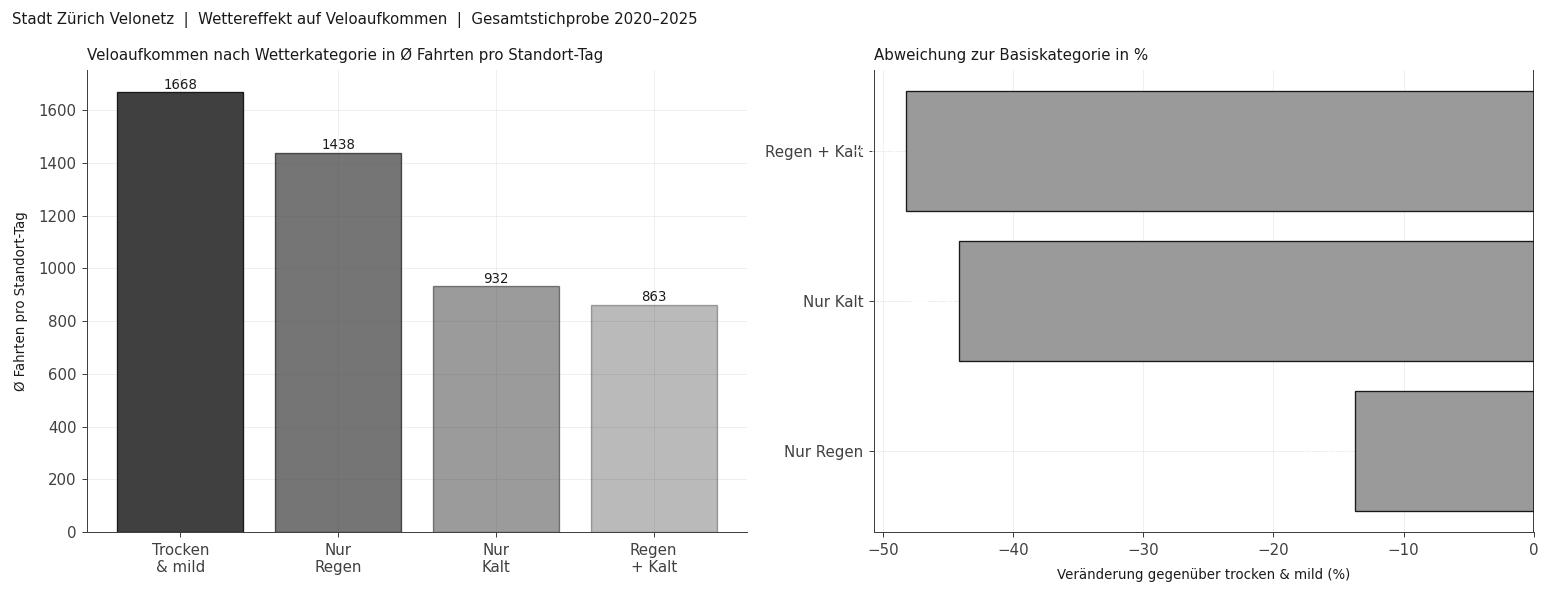

In [13]:
# Abb. 5-6: Wettereffekt – IBCS-konform + interaktiv
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.text(
    0.01, 0.98,
    'Stadt Zürich Velonetz  |  Wettereffekt auf Veloaufkommen  |  Gesamtstichprobe 2020–2025',
    fontsize=9, va='top', color='#1A1A1A'
)

kat_lab = ['Trocken\n& mild', 'Nur\nRegen', 'Nur\nKalt', 'Regen\n+ Kalt']
kat_val = [basis, nur_r, nur_k, beide]
alpha_v = [1.0, 0.72, 0.52, 0.36]

# Linke Grafik: Niveau je Wetterkategorie
bars_list = []
for lab_k, val_k, alph_k in zip(kat_lab, kat_val, alpha_v):
    b = axes[0].bar(
        lab_k, val_k,
        color=IBCS['AC'], alpha=alph_k,
        edgecolor='#1A1A1A', linewidth=0.8
    )
    bars_list.append(b[0])

ibcs_bar_label(axes[0], bars_list, kat_val)
ibcs_title(
    axes[0],
    'Veloaufkommen nach Wetterkategorie',
    'Ø Fahrten pro Standort-Tag'
)
axes[0].set_ylabel('Ø Fahrten pro Standort-Tag', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Rechte Grafik: Abweichung zur Basiskategorie
rueck = [(v - basis) / basis * 100 for v in [nur_r, nur_k, beide]]
kat2 = ['Nur Regen', 'Nur Kalt', 'Regen + Kalt']

# Einheitliche Graulogik statt semantisch unklarer PY-Farbe
farben2 = ['#9a9a9a', '#9a9a9a', '#9a9a9a']

b2 = axes[1].barh(
    kat2, rueck,
    color=farben2,
    edgecolor='#1A1A1A',
    linewidth=0.8
)
axes[1].axvline(x=0, color='#1A1A1A', linewidth=1.0)
ibcs_title(
    axes[1],
    'Abweichung zur Basiskategorie',
    '%'
)
axes[1].set_xlabel('Veränderung gegenüber trocken & mild (%)', fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)
ibcs_barh_label(axes[1], b2, rueck)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('abb_netzwerk.png', dpi=150, bbox_inches='tight')
plt.show()

# Interaktiver Plotly-Chart
if PLOTLY_OK:
    clrs = ['#404040', '#5a5a5a', '#7a7a7a', '#a0a0a0']
    fig_px = go.Figure()

    for i, (lab, val) in enumerate(zip(
        ['Trocken & mild', 'Nur Regen', 'Nur Kalt', 'Regen + Kalt'],
        kat_val
    )):
        delta = (val - basis) / basis * 100
        fig_px.add_trace(go.Bar(
            name=lab,
            x=[lab],
            y=[val],
            marker_color=clrs[i],
            text=f'{val:.0f} Velos ({delta:+.1f}%)',
            textposition='outside',
            hovertemplate=lab + ': %{y:.0f} Velos<extra></extra>'
        ))

    fig_px.update_layout(
        title='Veloaufkommen nach Wetterkategorie',
        yaxis_title='Ø Fahrten pro Standort-Tag',
        showlegend=False,
        plot_bgcolor='white',
        paper_bgcolor='white',
        font_family='Arial',
        height=420
    )
    fig_px.update_xaxes(showgrid=False)
    fig_px.update_yaxes(gridcolor='#E0E0E0')
    fig_px.show()

### 4.3 Standortebene: Abweichung vom Netzwerk-Durchschnitt (L3)

Die Analyse auf Standortebene zeigt, dass die Wettersensitivität innerhalb des Zürcher Velonetzes erheblich variiert. Der durchschnittliche standortspezifische Rückgang beträgt bei Regen −9.8 % und bei Kälte −34.7 %.

Besonders wettersensitiv gegenüber Regen sind vor allem Standorte an See- und Flussuferlagen, die tendenziell stärker freizeitorientiert genutzt werden. Am stärksten betroffen sind der Fischerweg mit einem Rückgang von −24.4 % (Abweichung zum Netzwerk: −14.6 Prozentpunkte), der Lux-Guyer-Weg mit −23.3 % (−13.5 Prozentpunkte) sowie der Mythenquai mit −19.4 % (−9.6 Prozentpunkte). Diese Standorte reagieren damit deutlich stärker auf Regen als das durchschnittliche Netz.

Demgegenüber zeigen einzelne innerstädtische Pendelrouten eine deutlich geringere Wettersensitivität. Die Schulstrasse (+4.8 %), die Talstrasse (+0.4 %) sowie der Stadttunnel Süd (−0.5 %) weisen im Vergleich zum Netzwerk nur geringe oder gar keine negativen Reaktionen auf Regen auf. Dies deutet darauf hin, dass diese Standorte auch bei ungünstigen Wetterbedingungen regelmässig genutzt werden und damit eine höhere funktionale Robustheit aufweisen.

Insgesamt deutet das Muster darauf hin, dass eher freizeitorientierte Routen stärker wetterabhängig sind, während alltags- und pendelorientierte Verbindungen robuster genutzt werden.

Zu beachten ist, dass der hier verwendete Netzwerk-Durchschnitt als Mittelwert der standortspezifischen Rückgänge berechnet wird. Er unterscheidet sich damit methodisch von der aggregierten Netzwerkbetrachtung in Kapitel 4.2.


In [14]:
from IPython.display import display, HTML

def rueckgang(grp, col, min_obs=30):
    gut      = grp[~grp[col]]
    schlecht = grp[ grp[col]]
    if len(gut) < min_obs or len(schlecht) < min_obs:
        return np.nan
    mu_gut  = gut['VELO_TOTAL'].mean()
    mu_schl = schlecht['VELO_TOTAL'].mean()
    if pd.isna(mu_gut) or mu_gut == 0 or pd.isna(mu_schl):
        return np.nan
    return (mu_schl - mu_gut) / mu_gut * 100

sens_r = (df.groupby(['FK_STANDORT','bezeichnung'])
            .apply(lambda g: rueckgang(g,'REGEN'))
            .reset_index(name='RUECKGANG_REGEN_PCT'))
sens_k = (df.groupby(['FK_STANDORT','bezeichnung'])
            .apply(lambda g: rueckgang(g,'KALT'))
            .reset_index(name='RUECKGANG_KALT_PCT'))
sens_b = (df.groupby(['FK_STANDORT','bezeichnung'])
            .apply(lambda g: rueckgang(g,'BEIDE'))
            .reset_index(name='RUECKGANG_BEIDE_PCT'))

sens_raw = sens_r.merge(sens_k, on=['FK_STANDORT','bezeichnung'])
sens_raw = sens_raw.merge(sens_b, on=['FK_STANDORT','bezeichnung'])

sens = (sens_raw.groupby('bezeichnung', as_index=False)
        .agg(
            RUECKGANG_REGEN_PCT=('RUECKGANG_REGEN_PCT', 'mean'),
            RUECKGANG_KALT_PCT =('RUECKGANG_KALT_PCT',  'mean'),
            RUECKGANG_BEIDE_PCT=('RUECKGANG_BEIDE_PCT',  'mean'),
        )
        .dropna(subset=['RUECKGANG_REGEN_PCT','RUECKGANG_KALT_PCT']))

netz_r = sens['RUECKGANG_REGEN_PCT'].mean()
netz_k = sens['RUECKGANG_KALT_PCT'].mean()
netz_b = sens['RUECKGANG_BEIDE_PCT'].mean()
sens['ABWEICHUNG_REGEN'] = (sens['RUECKGANG_REGEN_PCT'] - netz_r).round(1)
sens['ABWEICHUNG_KALT']  = (sens['RUECKGANG_KALT_PCT']  - netz_k).round(1)
sens['ABWEICHUNG_BEIDE'] = (sens['RUECKGANG_BEIDE_PCT']  - netz_b).round(1)

def ranking_rows(df_rank, col, abw_col):
    html = ''
    for _, row in df_rank.iterrows():
        farbe = '#cc0000' if row[col] < 0 else '#1a6600'
        html += (
            "<tr style='border-bottom:1px solid #e8e8e8'>"
            "<td style='padding:4px 10px'>" + str(row['bezeichnung']) + "</td>"
            "<td style='padding:4px 10px;text-align:right;font-weight:600;color:" + farbe + "'>"
            + f"{row[col]:+.1f}%" + "</td>"
            "<td style='padding:4px 10px;text-align:right;color:#888'>"
            + f"{row[abw_col]:+.1f}%" + "</td>"
            "</tr>"
        )
    return html

top10_r = sens.nsmallest(10, 'RUECKGANG_REGEN_PCT')
top10_k = sens.nsmallest(10, 'RUECKGANG_KALT_PCT')

header = (
    "<tr style='background:#f0f0f0;color:#555;font-size:10px'>"
    "<th style='padding:5px 10px;text-align:left'>Standort</th>"
    "<th style='padding:5px 10px;text-align:right'>Rückgang</th>"
    "<th style='padding:5px 10px;text-align:right'>Abw. Netz</th>"
    "</tr>"
)

kacheln = (
    "<div style='flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #404040'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>Netz-Ø Regen</div>"
    "<div style='font-size:20px;font-weight:700;color:#cc0000'>" + f"{netz_r:+.1f}%" + "</div>"
    "<div style='font-size:9px;color:#aaa'>" + str(len(sens)) + " Standorte</div>"
    "</div>"
    "<div style='flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #a0a0a0;margin-left:6px'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>Netz-Ø Kälte</div>"
    "<div style='font-size:20px;font-weight:700;color:#cc0000'>" + f"{netz_k:+.1f}%" + "</div>"
    "<div style='font-size:9px;color:#aaa'>Tagesmittel max. 5 Grad</div>"
    "</div>"
    "<div style='flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid #c8c8c8;margin-left:6px'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>Netz-Ø Regen+Kälte</div>"
    "<div style='font-size:20px;font-weight:700;color:#cc0000'>" + f"{netz_b:+.1f}%" + "</div>"
    "<div style='font-size:9px;color:#aaa'>Kombinierter Effekt</div>"
    "</div>"
)

html_out = (
    "<div style='font-family:Arial;font-size:12px;max-width:700px'>"
    "<div style='background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em'>"
    "WETTERSENSITIVITÄT  |  Standortebene  |  min. 30 Beobachtungen pro Kategorie"
    "</div>"
    "<div style='display:flex;gap:6px;margin-top:8px'>" + kacheln + "</div>"
    "<div style='display:flex;gap:8px;margin-top:10px'>"
    "<div style='flex:1'>"
    "<div style='font-size:11px;font-weight:600;padding:5px 10px;background:#f0f0f0;color:#404040'>"
    "Top 10 sensibelste Standorte  |  Regen</div>"
    "<table style='width:100%;border-collapse:collapse;font-size:11px'>"
    + header + ranking_rows(top10_r, 'RUECKGANG_REGEN_PCT', 'ABWEICHUNG_REGEN') +
    "</table></div>"
    "<div style='flex:1'>"
    "<div style='font-size:11px;font-weight:600;padding:5px 10px;background:#f0f0f0;color:#404040'>"
    "Top 10 sensibelste Standorte  |  Kälte</div>"
    "<table style='width:100%;border-collapse:collapse;font-size:11px'>"
    + header + ranking_rows(top10_k, 'RUECKGANG_KALT_PCT', 'ABWEICHUNG_KALT') +
    "</table></div>"
    "</div></div>"
)

display(HTML(html_out))

Standort,Rückgang,Abw. Netz
Mythenquai,-18.9%,-9.2%
Limmatquai --> Bellevue,-16.8%,-7.1%
Tödistrasse,-16.0%,-6.3%
Andreasstrasse,-14.9%,-5.2%
Lux-Guyer-Weg,-13.8%,-4.1%
Limmatquai --> Central,-13.0%,-3.3%
Sihlpromenade,-11.9%,-2.1%
Tannenrauchstrasse,-11.7%,-2.0%
Hofwiesenstrasse,-11.4%,-1.6%
Baslerstrasse,-10.9%,-1.2%


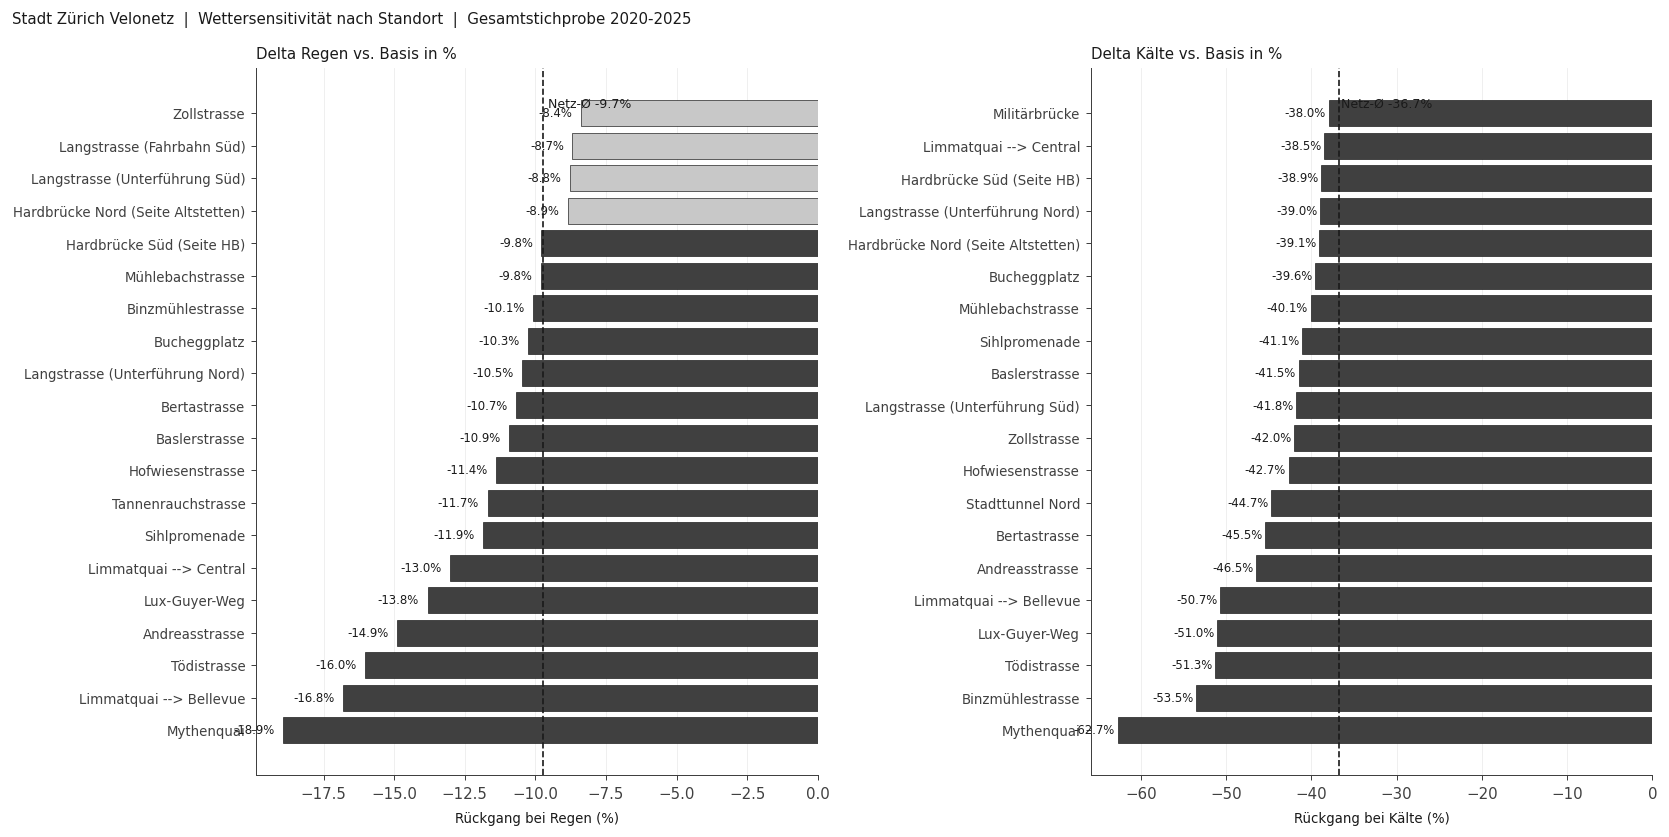

In [15]:
# Abb. 7-8: Regen- und Kälte-Sensitivitaet nach Standort
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.text(0.01, 0.99, 'Stadt Zürich Velonetz  |  Wettersensitivität nach Standort  |  Gesamtstichprobe 2020-2025',
         fontsize=9, va='top', color='#1A1A1A')

for ax, col, netz_val, kennzahl, xlabel in [
    (axes[0], 'RUECKGANG_REGEN_PCT', netz_r, 'Delta Regen vs. Basis', 'Rückgang bei Regen (%)'),
    (axes[1], 'RUECKGANG_KALT_PCT',  netz_k, 'Delta Kälte vs. Basis', 'Rückgang bei Kälte (%)'),
]:
    df_p   = sens.dropna(subset=[col]).sort_values(col).head(20)
    farben = [IBCS['AC'] if v < netz_val else IBCS['neutral'] for v in df_p[col]]
    bars   = ax.barh(df_p['bezeichnung'], df_p[col],
                     color=farben, edgecolor='#1A1A1A', linewidth=0.4)
    ax.axvline(x=netz_val, color=IBCS['ref_line'], linestyle='--', linewidth=1.0)
    ax.text(netz_val+0.2, len(df_p)-0.5,
            f'Netz-Ø {netz_val:.1f}%', fontsize=7.5, va='top', color='#1A1A1A')
    ibcs_title(ax, kennzahl, '%')
    ax.set_xlabel(xlabel, fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', color='#E0E0E0', linewidth=0.5)
    ax.grid(axis='y', visible=False)
    for bar, v in zip(bars, df_p[col]):
        xoff = v - 0.3 if v < 0 else v + 0.3
        ha   = 'right' if v < 0 else 'left'
        ax.text(xoff, bar.get_y()+bar.get_height()/2,
                f'{v:.1f}%', ha=ha, va='center', fontsize=7, color='#1A1A1A')

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('abb_standorte.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interaktiver Bubble-Chart: Regen vs. Kaelte-Sensitivitaet ────────────────
if PLOTLY_OK:
    vol_st = df.groupby('bezeichnung')['VELO_TOTAL'].mean().reset_index()
    vol_st.columns = ['bezeichnung','avg_velo']
    sens_plot = sens.merge(vol_st, on='bezeichnung', how='left')

    fig_bubble = px.scatter(
        sens_plot,
        x='RUECKGANG_REGEN_PCT', y='RUECKGANG_KALT_PCT',
        size='avg_velo', size_max=30, text='bezeichnung',
        color_discrete_sequence=['#404040'],
        labels={'RUECKGANG_REGEN_PCT':'Regen-Rückgang (%)',
                'RUECKGANG_KALT_PCT':'Kaelte-Rückgang (%)'},
        title='Standort-Profil: Regen- vs. Kälte-Sensitivität (Grösse = Ø Velo/Tag)',
    )
    fig_bubble.add_hline(y=netz_k, line_dash='dash', line_color='#A0A0A0',
                         annotation_text=f'Netz-Ø Kaelte {netz_k:.1f}%')
    fig_bubble.add_vline(x=netz_r, line_dash='dash', line_color='#A0A0A0',
                         annotation_text=f'Netz-Ø Regen {netz_r:.1f}%')
    fig_bubble.update_traces(textposition='top center', marker_color='#404040')
    fig_bubble.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                             font_family='Arial', height=550)
    fig_bubble.update_xaxes(gridcolor='#E0E0E0')
    fig_bubble.update_yaxes(gridcolor='#E0E0E0')
    fig_bubble.show()

---
#### 4.3.1 Unterschied bei starkem Regen

Die folgende Grafik zeigt, wie sich das Veloaufkommen in Abhängigkeit von der Niederschlagsintensität (gemessen als Niederschlagsdauer) verändert. Regentage werden in Intensitätsstufen unterteilt, um zu prüfen, ob der Rückgang progressiv mit der Niederschlagsdauer ansteigt oder ab einem gewissen Schwellenwert stagniert.

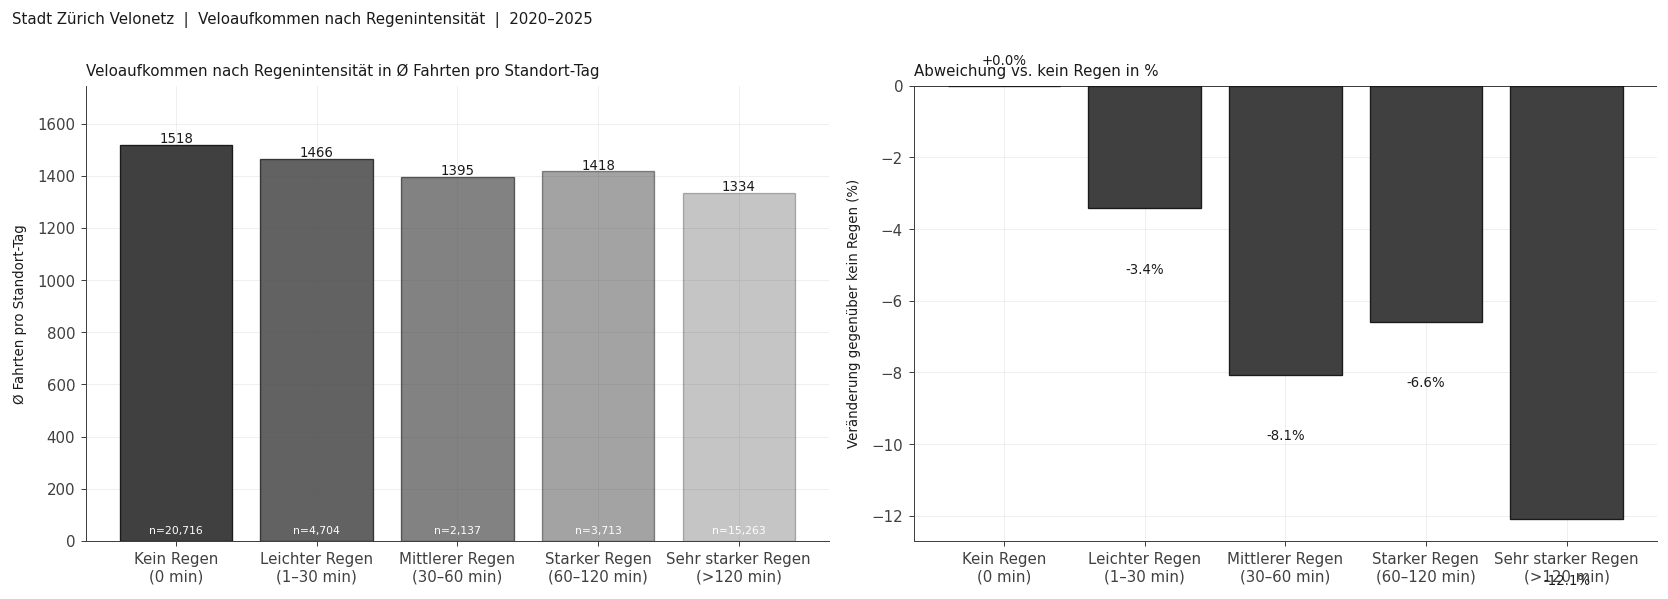

Abb. Starkregen gespeichert.


In [16]:
# ── Abb.: Veloaufkommen nach Regenintensität ────────────────────────────────
regen_stufen = [
    ('Kein Regen\n(0 min)',           df[df['rain_dur'] == 0]),
    ('Leichter Regen\n(1–30 min)',    df[(df['rain_dur'] > 0)  & (df['rain_dur'] <= 30)]),
    ('Mittlerer Regen\n(30–60 min)',  df[(df['rain_dur'] > 30) & (df['rain_dur'] <= 60)]),
    ('Starker Regen\n(60–120 min)',   df[(df['rain_dur'] > 60) & (df['rain_dur'] <= 120)]),
    ('Sehr starker Regen\n(>120 min)',df[df['rain_dur'] > 120]),
]

labels_r   = [s[0] for s in regen_stufen]
means_r    = [s[1]['VELO_TOTAL'].mean() for s in regen_stufen]
counts_r   = [len(s[1]) for s in regen_stufen]
basis_kein = means_r[0]
delta_r    = [(v - basis_kein) / basis_kein * 100 for v in means_r]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.text(0.01, 0.99,
    'Stadt Zürich Velonetz  |  Veloaufkommen nach Regenintensität  |  2020–2025',
    fontsize=9, va='top', color='#1A1A1A')

alphas_r = [1.0, 0.82, 0.65, 0.48, 0.30]

bars_r = []
for lab, val, alph in zip(labels_r, means_r, alphas_r):
    b = axes[0].bar(lab, val, color=IBCS['AC'], alpha=alph,
                    edgecolor='#1A1A1A', linewidth=0.8)
    bars_r.append(b[0])
    axes[0].text(b[0].get_x() + b[0].get_width()/2, val + 8,
                 f'{val:.0f}', ha='center', fontsize=8, color='#1A1A1A')

for bar, n in zip(bars_r, counts_r):
    axes[0].text(bar.get_x() + bar.get_width()/2, 20,
                 f'n={n:,}', ha='center', fontsize=6.5, color='white', va='bottom')

ibcs_title(axes[0], 'Veloaufkommen nach Regenintensität', 'Ø Fahrten pro Standort-Tag')
axes[0].set_ylabel('Ø Fahrten pro Standort-Tag', fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, max(means_r) * 1.15)

farben_d = [IBCS['neutral'] if d >= 0 else IBCS['AC'] for d in delta_r]
b2 = axes[1].bar(labels_r, delta_r, color=farben_d, edgecolor='#1A1A1A', linewidth=0.8)
axes[1].axhline(y=0, color='#1A1A1A', linewidth=1.0)
for bar, d in zip(b2, delta_r):
    ypos = d + 0.5 if d >= 0 else d - 1.5
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                 f'{d:+.1f}%', ha='center', fontsize=8, color='#1A1A1A',
                 va='bottom' if d >= 0 else 'top')
ibcs_title(axes[1], 'Abweichung vs. kein Regen', '%')
axes[1].set_ylabel('Veränderung gegenüber kein Regen (%)', fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('abb_starkregen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Abb. Starkregen gespeichert.')

if PLOTLY_OK:
    clrs_sr = ['#404040','#5a5a5a','#747474','#8e8e8e','#a8a8a8']
    fig_sr = go.Figure()
    for i, (lab, val, d, n) in enumerate(zip(labels_r, means_r, delta_r, counts_r)):
        fig_sr.add_trace(go.Bar(
            name=lab.replace('\n',' '),
            x=[lab.replace('\n',' ')],
            y=[val],
            marker_color=clrs_sr[i],
            text=f'{val:.0f} Velos ({d:+.1f}%)<br>n={n:,}',
            textposition='outside',
            hovertemplate=lab.replace('\n',' ') + ': %{y:.0f} Velos<extra></extra>'
        ))
    fig_sr.update_layout(
        title='Veloaufkommen nach Regenintensität (Niederschlagsdauer)',
        yaxis_title='Ø Fahrten pro Standort-Tag',
        showlegend=False, plot_bgcolor='white', paper_bgcolor='white',
        font_family='Arial', height=440)
    fig_sr.update_xaxes(showgrid=False)
    fig_sr.update_yaxes(gridcolor='#E0E0E0')
    fig_sr.show()

---
#### 4.3.2 Kombinierter Effekt: Regen + Kälte nach Standort

Die folgende Grafik zeigt den kombinierten Wettereffekt (gleichzeitig Regen **und** Kälte) auf Standortebene im Vergleich zu den Einzeleffekten. Standorte, die bei kombiniertem Schlechtwetter besonders stark reagieren, weisen die grössten Herausforderungen für eine ganzjährige Alltagstauglichkeit auf.

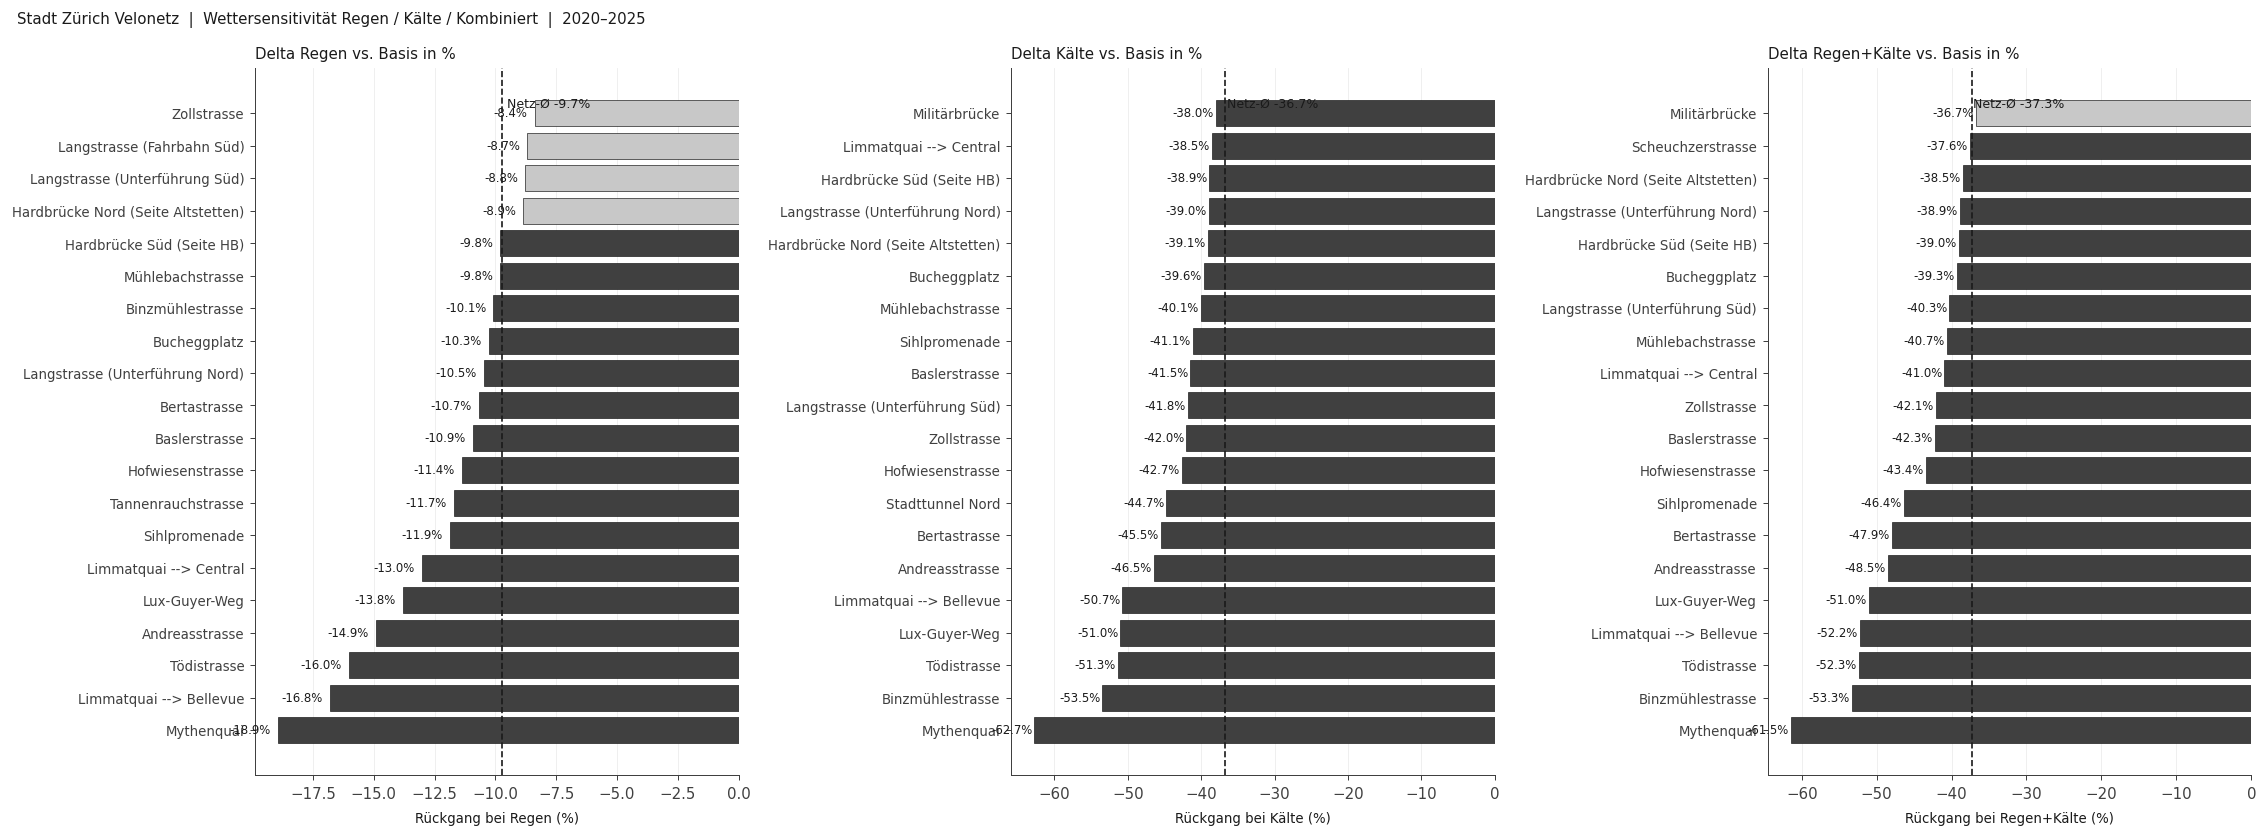

Abb. Kombinierter Effekt gespeichert.


In [17]:
# ── Abb.: Kombinierter Effekt Regen + Kälte nach Standort ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 7))
fig.text(0.01, 0.99,
    'Stadt Zürich Velonetz  |  Wettersensitivität Regen / Kälte / Kombiniert  |  2020–2025',
    fontsize=9, va='top', color='#1A1A1A')

plot_configs = [
    ('RUECKGANG_REGEN_PCT', netz_r, 'Delta Regen vs. Basis',      'Rückgang bei Regen (%)'),
    ('RUECKGANG_KALT_PCT',  netz_k, 'Delta Kälte vs. Basis',      'Rückgang bei Kälte (%)'),
    ('RUECKGANG_BEIDE_PCT', netz_b, 'Delta Regen+Kälte vs. Basis','Rückgang bei Regen+Kälte (%)'),
]

for ax, (col, netz_val, kennzahl, xlabel) in zip(axes, plot_configs):
    df_p   = sens.dropna(subset=[col]).sort_values(col).head(20)
    farben = [IBCS['AC'] if v < netz_val else IBCS['neutral'] for v in df_p[col]]
    bars   = ax.barh(df_p['bezeichnung'], df_p[col],
                     color=farben, edgecolor='#1A1A1A', linewidth=0.4)
    ax.axvline(x=netz_val, color=IBCS['ref_line'], linestyle='--', linewidth=1.0)
    ax.text(netz_val + 0.2, len(df_p) - 0.5,
            f'Netz-Ø {netz_val:.1f}%', fontsize=7.5, va='top', color='#1A1A1A')
    ibcs_title(ax, kennzahl, '%')
    ax.set_xlabel(xlabel, fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', color='#E0E0E0', linewidth=0.5)
    ax.grid(axis='y', visible=False)
    for bar, v in zip(bars, df_p[col]):
        xoff = v - 0.3 if v < 0 else v + 0.3
        ha   = 'right' if v < 0 else 'left'
        ax.text(xoff, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', ha=ha, va='center', fontsize=7, color='#1A1A1A')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('abb_kombiniert.png', dpi=150, bbox_inches='tight')
plt.show()
print('Abb. Kombinierter Effekt gespeichert.')

# Interaktiver Bubble-Chart: Kombi-Effekt
if PLOTLY_OK:
    vol_st = df.groupby('bezeichnung')['VELO_TOTAL'].mean().reset_index()
    vol_st.columns = ['bezeichnung','avg_velo']
    sens_plot = sens.merge(vol_st, on='bezeichnung', how='left')

    fig_bubble = px.scatter(
        sens_plot.dropna(subset=['RUECKGANG_REGEN_PCT','RUECKGANG_KALT_PCT','RUECKGANG_BEIDE_PCT']),
        x='RUECKGANG_REGEN_PCT', y='RUECKGANG_KALT_PCT',
        size='avg_velo', size_max=30, text='bezeichnung',
        color='RUECKGANG_BEIDE_PCT',
        color_continuous_scale=[[0,'#1a1a1a'],[0.5,'#808080'],[1,'#d0d0d0']],
        labels={
            'RUECKGANG_REGEN_PCT': 'Regen-Rückgang (%)',
            'RUECKGANG_KALT_PCT':  'Kälte-Rückgang (%)',
            'RUECKGANG_BEIDE_PCT': 'Regen+Kälte (%)'
        },
        title='Standort-Profil: Kombi-Effekt<br>'
              '(Grösse = Ø Velo/Tag | Farbe = Regen+Kälte kombiniert)',
    )
    fig_bubble.add_hline(y=netz_k, line_dash='dash', line_color='#A0A0A0',
                         annotation_text=f'Netz-Ø Kälte {netz_k:.1f}%')
    fig_bubble.add_vline(x=netz_r, line_dash='dash', line_color='#A0A0A0',
                         annotation_text=f'Netz-Ø Regen {netz_r:.1f}%')
    fig_bubble.update_traces(textposition='top center')
    fig_bubble.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                             font_family='Arial', height=580)
    fig_bubble.update_xaxes(gridcolor='#E0E0E0')
    fig_bubble.update_yaxes(gridcolor='#E0E0E0')
    fig_bubble.show()

---
#### 4.3.3 Karte: Velostandorte und Messstation in der Stadt Zürich

Die folgende Karte visualisiert die geografische Lage der 46 automatischen Velozählstellen sowie der meteorologischen Messstation Stampfenbachstrasse im Stadtgebiet Zürich. Die Einfärbung der Marker gibt die Regen-Sensitivität des jeweiligen Standorts wieder — dunklere Marker entsprechen einer höheren Wettersensitivität.

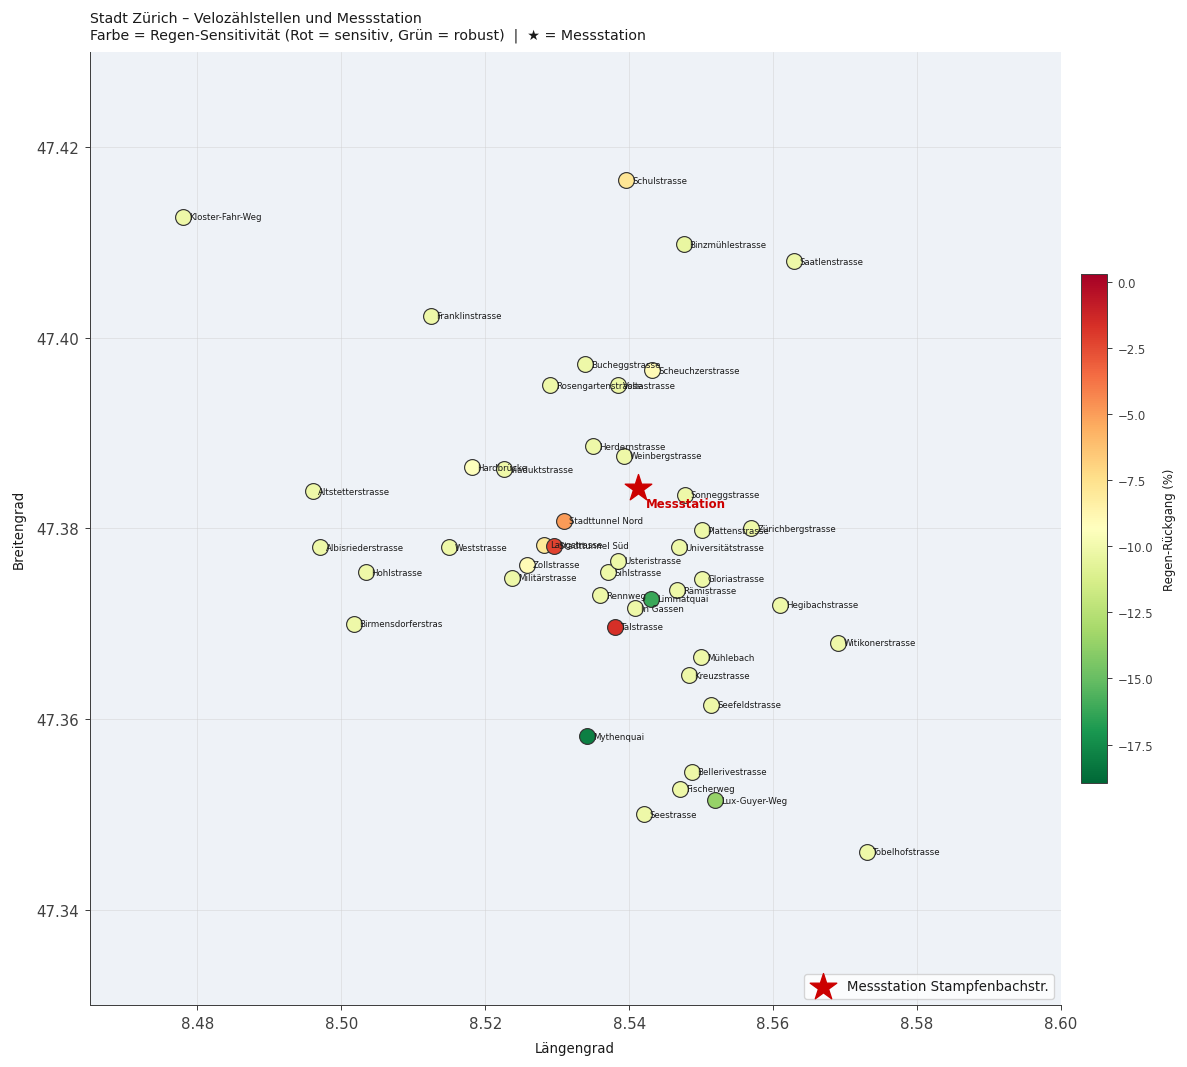

Abb. Karte Zürich gespeichert.


In [18]:
# ── Abb.: Stadt Zürich Karte mit Velostandorten und Messstation ──────────────
# Koordinaten der Velozählstellen (approximativ, Open Data Stadt Zürich)
standort_koordinaten = {
    'Altstetterstrasse':    (47.3839, 8.4960),
    'Binzmühlestrasse':     (47.4098, 8.5476),
    'Fischerweg':           (47.3527, 8.5471),
    'Franklinstrasse':      (47.4023, 8.5124),
    'Hardbrücke':           (47.3864, 8.5181),
    'Hohlstrasse':          (47.3754, 8.5034),
    'In Gassen':            (47.3716, 8.5408),
    'Kloster-Fahr-Weg':     (47.4127, 8.4780),
    'Langstrasse':          (47.3783, 8.5282),
    'Lux-Guyer-Weg':        (47.3515, 8.5520),
    'Militärstrasse':       (47.3748, 8.5237),
    'Mythenquai':           (47.3582, 8.5342),
    'Scheuchzerstrasse':    (47.3966, 8.5432),
    'Schulstrasse':         (47.4165, 8.5396),
    'Seefeldstrasse':       (47.3615, 8.5514),
    'Sihlstrasse':          (47.3754, 8.5371),
    'Stadttunnel Nord':     (47.3808, 8.5309),
    'Stadttunnel Süd':      (47.3782, 8.5295),
    'Talstrasse':           (47.3697, 8.5380),
    'Tobelhofstrasse':      (47.3461, 8.5731),
    'Usteristrasse':        (47.3766, 8.5385),
    'Viaduktstrasse':       (47.3862, 8.5226),
    'Weinbergstrasse':      (47.3876, 8.5393),
    'Weststrasse':          (47.3780, 8.5150),
    'Zollstrasse':          (47.3762, 8.5258),
    'Rosengartenstrasse':   (47.3950, 8.5290),
    'Bucheggstrasse':       (47.3972, 8.5339),
    'Rennweg':              (47.3730, 8.5360),
    'Rämistrasse':          (47.3735, 8.5467),
    'Gloriastrasse':        (47.3747, 8.5501),
    'Universitätstrasse':   (47.3780, 8.5470),
    'Plattenstrasse':       (47.3798, 8.5501),
    'Sonneggstrasse':       (47.3835, 8.5477),
    'Voltastrasse':         (47.3950, 8.5384),
    'Saatlenstrasse':       (47.4080, 8.5629),
    'Birmensdorferstrasse': (47.3700, 8.5017),
    'Herdernstrasse':       (47.3886, 8.5350),
    'Limmatquai':           (47.3726, 8.5431),
    'Mühlebach':            (47.3665, 8.5500),
    'Kreuzstrasse':         (47.3646, 8.5483),
    'Bellerivestrasse':     (47.3545, 8.5487),
    'Seestrasse':           (47.3500, 8.5420),
    'Zürichbergstrasse':    (47.3800, 8.5570),
    'Hegibachstrasse':      (47.3720, 8.5610),
    'Witikonerstrasse':     (47.3680, 8.5690),
    'Albisriederstrasse':   (47.3780, 8.4970),
}
messstation_koord = (47.3842, 8.5413)  # Stampfenbachstrasse

sens_dict = dict(zip(sens['bezeichnung'], sens['RUECKGANG_REGEN_PCT']))

# Sensitivitätswert pro Standort (fuzzy match über Teilstring)
def get_sensitivity(name):
    name_l = name.lower()
    for k, v in sens_dict.items():
        if name_l in k.lower() or k.lower() in name_l:
            return v
    return netz_r  # Fallback: Netz-Durchschnitt

# ── Plotly Scattermapbox ──────────────────────────────────────────────────────
if PLOTLY_OK:
    lats, lons, names_k, colors_k, hover_k = [], [], [], [], []
    for name, (lat, lon) in standort_koordinaten.items():
        sv = get_sensitivity(name)
        lats.append(lat); lons.append(lon); names_k.append(name)
        colors_k.append(sv)
        hover_k.append(f'<b>{name}</b><br>Regen-Rückgang: {sv:.1f}%')

    fig_map = go.Figure()
    fig_map.add_trace(go.Scattermapbox(
        lat=lats, lon=lons, mode='markers',
        marker=dict(
            size=14,
            color=colors_k,
            colorscale=[[0,'#1a1a1a'],[0.5,'#707070'],[1,'#d8d8d8']],
            cmin=min(colors_k), cmax=max(colors_k),
            colorbar=dict(title='Regen-Rückgang (%)', thickness=12, len=0.6,
                          titlefont=dict(size=10)),
            showscale=True,
        ),
        hovertext=hover_k, hoverinfo='text',
        name='Velozählstellen (n=46)',
    ))
    fig_map.add_trace(go.Scattermapbox(
        lat=[messstation_koord[0]], lon=[messstation_koord[1]],
        mode='markers+text',
        marker=dict(size=20, color='#cc0000', symbol='star'),
        text=['Messstation'], textposition='bottom right',
        textfont=dict(size=9, color='#cc0000'),
        hovertext=['Messstation Stampfenbachstrasse'], hoverinfo='text',
        name='Messstation Meteo',
    ))
    fig_map.update_layout(
        mapbox=dict(style='carto-positron',
                    center=dict(lat=47.382, lon=8.535), zoom=12),
        title=dict(
            text='Stadt Zürich – Velozählstellen und Messstation<br>'
                 '<sup>Farbe = Regen-Sensitivität | Dunkel = sensitiv | ★ = Messstation Stampfenbachstrasse</sup>',
            font=dict(size=13)),
        legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01,
                    bgcolor='rgba(255,255,255,0.85)', bordercolor='#ccc', borderwidth=1),
        margin=dict(l=0, r=0, t=70, b=0), height=620, paper_bgcolor='white',
    )
    fig_map.show()
    print('Interaktive Karte mit 46 Velostandorten angezeigt.')

# ── Matplotlib Karte (Fallback) ───────────────────────────────────────────────
fig_mk, ax_mk = plt.subplots(figsize=(10, 9))
ax_mk.set_facecolor('#eef2f7')
fig_mk.patch.set_facecolor('white')

vmin_s = sens['RUECKGANG_REGEN_PCT'].min()
vmax_s = sens['RUECKGANG_REGEN_PCT'].max()

for name, (lat, lon) in standort_koordinaten.items():
    sv  = get_sensitivity(name)
    norm = (sv - vmin_s) / (vmax_s - vmin_s) if (vmax_s - vmin_s) != 0 else 0.5
    col = plt.cm.RdYlGn_r(norm * 0.85 + 0.05)  # Gelb-Grün-Rot: sensibel=rot
    ax_mk.scatter(lon, lat, c=[col], s=90, edgecolors='#333', linewidth=0.7, zorder=3)
    ax_mk.text(lon + 0.0008, lat, name[:18], fontsize=5.2, color='#1a1a1a', va='center', zorder=4)

# Messstation
ax_mk.scatter(messstation_koord[1], messstation_koord[0],
              marker='*', s=280, c='#cc0000', zorder=5, label='Messstation Stampfenbachstr.')
ax_mk.text(messstation_koord[1] + 0.001, messstation_koord[0] - 0.002,
           'Messstation', fontsize=7, color='#cc0000', fontweight='bold', zorder=6)

ax_mk.set_xlim(8.465, 8.600)
ax_mk.set_ylim(47.330, 47.430)
ax_mk.set_xlabel('Längengrad', fontsize=8)
ax_mk.set_ylabel('Breitengrad', fontsize=8)
ax_mk.set_title(
    'Stadt Zürich – Velozählstellen und Messstation\n'
    'Farbe = Regen-Sensitivität (Rot = sensitiv, Grün = robust)  |  ★ = Messstation',
    loc='left', fontsize=8.5)
ax_mk.legend(frameon=True, fontsize=8, loc='lower right')
ax_mk.spines[['top','right']].set_visible(False)
ax_mk.grid(True, color='#ccc', linewidth=0.4)

sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=plt.Normalize(vmin=vmin_s, vmax=vmax_s))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_mk, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Regen-Rückgang (%)', fontsize=7)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('abb_karte_zuerich.png', dpi=150, bbox_inches='tight')
plt.show()
print('Abb. Karte Zürich gespeichert.')

### 4.4 Zeitliche Entwicklung 2020–2025 (L4)

Die zeitliche Entwicklung zeigt zwei wesentliche Trends:

**Veloaufkommen:** Das Netzwerk-Veloaufkommen stieg von 1'434 Velos/Tag (2020) auf 1'572 Velos/Tag (2025), entsprechend einem Trend von +38.9 Velos/Jahr (p=0.135, statistisch nicht signifikant). Der Einbruch 2021 ist möglicherweise auf COVID-19-bedingte Verhaltensänderungen zurückzuführen.

**Kälte-Sensitivität:** Die Kälte-Sensitivität zeigt eine leichte Abnahme von −43.9% (2020) auf −36.3% (2025), Trend +1.2 Prozentpunkte/Jahr (p=0.076, knapp nicht signifikant). Diese Entwicklung könnte auf Infrastrukturverbesserungen oder veränderte Nutzungsgewohnheiten zurückzuführen sein.

Zu beachten ist, dass die Trendanalyse auf lediglich sechs Jahreswerten basiert. Die Aussagekraft statistischer Signifikanztests ist daher begrenzt und die Ergebnisse sind entsprechend vorsichtig zu interpretieren.


In [19]:
from IPython.display import display, HTML

trend = []
for j in ANALYSE_JAHRE:
    g   = df[df['JAHR']==j]
    vo  = g['VELO_TOTAL'].mean()
    vt2 = g[~g['REGEN']]['VELO_TOTAL'].mean()
    vr2 = g[ g['REGEN']]['VELO_TOTAL'].mean()
    vm2 = g[~g['KALT']]['VELO_TOTAL'].mean()
    vk2 = g[ g['KALT']]['VELO_TOTAL'].mean()
    rr2 = (vr2-vt2)/vt2*100 if vt2>0 else np.nan
    rk2 = (vk2-vm2)/vm2*100 if vm2>0 else np.nan
    trend.append({'Jahr':j,'Velo':vo,'Regen':rr2,'Kalt':rk2})

df_trend = pd.DataFrame(trend)

trends = {}
for col, label in [('Velo','Veloaufkommen'), ('Kalt','Kälte-Sensitivität')]:
    v = df_trend[['Jahr',col]].dropna()
    sl, ic, r, p, se = stats.linregress(v['Jahr'], v[col])
    trends[col] = {'sl': sl, 'p': p, 'label': label}

# Tabellenzeilen
data_rows = ''
for row in df_trend.itertuples():
    r_col = '#cc0000' if row.Regen < 0 else '#1a6600'
    k_col = '#cc0000' if row.Kalt  < 0 else '#1a6600'
    data_rows += (
        "<tr style='border-bottom:1px solid #e8e8e8'>"
        f"<td style='padding:5px 10px;font-weight:600'>{row.Jahr}</td>"
        f"<td style='padding:5px 10px;text-align:right'>{row.Velo:,.0f}</td>"
        f"<td style='padding:5px 10px;text-align:right;color:{r_col};font-weight:600'>{row.Regen:+.1f}%</td>"
        f"<td style='padding:5px 10px;text-align:right;color:{k_col};font-weight:600'>{row.Kalt:+.1f}%</td>"
        "</tr>"
    )

# Trend-Kacheln
def trend_kachel(col, border):
    t   = trends[col]
    sig = "signifikant" if t['p'] < 0.05 else "nicht signifikant"
    sig_col = '#1a6600' if t['p'] < 0.05 else '#888'
    return (
        f"<div style='flex:1;background:#f7f7f7;padding:8px 12px;border-left:3px solid {border}'>"
        f"<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>Trend {t['label']}</div>"
        f"<div style='font-size:20px;font-weight:700;color:#1a1a1a'>{t['sl']:+.1f}<span style='font-size:11px;font-weight:400'> /Jahr</span></div>"
        f"<div style='font-size:10px;color:{sig_col};margin-top:2px'>{sig} (p={t['p']:.3f})</div>"
        "</div>"
    )

html_out = (
    "<div style='font-family:Arial;font-size:12px;max-width:580px'>"
    "<div style='background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em'>"
    "ZEITLICHE ENTWICKLUNG  |  2020–2025"
    "</div>"
    "<table style='width:100%;border-collapse:collapse;font-size:11px;margin-top:8px'>"
    "<tr style='background:#f0f0f0;color:#555;font-size:10px'>"
    "<th style='padding:5px 10px;text-align:left'>Jahr</th>"
    "<th style='padding:5px 10px;text-align:right'>Ø Velo/Tag</th>"
    "<th style='padding:5px 10px;text-align:right'>Regen-Rückgang</th>"
    "<th style='padding:5px 10px;text-align:right'>Kälte-Rückgang</th>"
    "</tr>"
    + data_rows +
    "</table>"
    "<div style='display:flex;gap:6px;margin-top:10px'>"
    + trend_kachel('Velo', '#404040')
    + trend_kachel('Kalt', '#a0a0a0') +
    "</div>"
    "</div>"
)

display(HTML(html_out))

Jahr,Ø Velo/Tag,Regen-Rückgang,Kälte-Rückgang
2020,"1,434",-10.9%,-43.9%
2021,"1,241",-14.9%,-43.6%
2022,"1,417",-5.7%,-40.8%
2023,"1,445",-17.0%,-43.1%
2024,"1,455",-4.5%,-41.9%
2025,"1,624",-7.3%,-37.5%


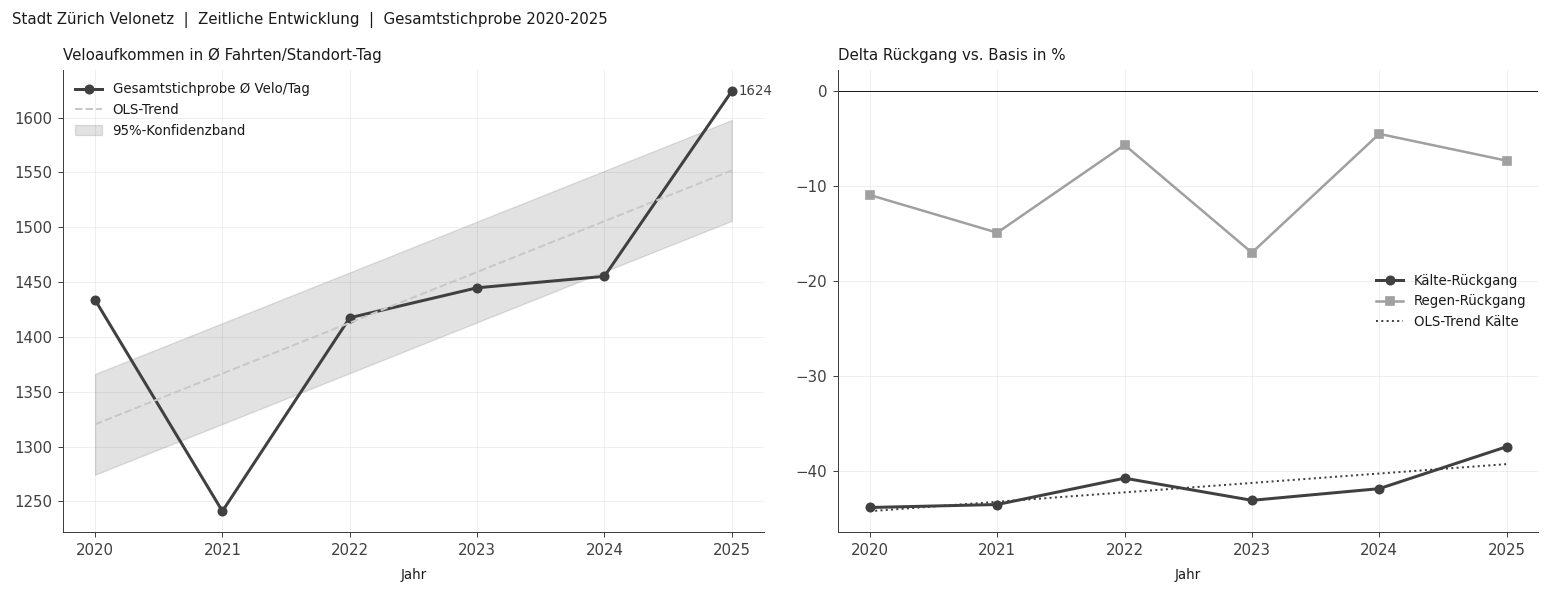

In [20]:
# Abb. 9-10: Zeitliche Entwicklung – IBCS + Konfidenzband (Vorhersage)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.text(0.01, 0.98, 'Stadt Zürich Velonetz  |  Zeitliche Entwicklung  |  Gesamtstichprobe 2020-2025',
         fontsize=9, va='top', color='#1A1A1A')

jahre = df_trend['Jahr']

# Abb. 9: Veloaufkommen – IBCS AC-Linie
axes[0].plot(jahre, df_trend['Velo'], 'o-', color=IBCS['AC'],
             markersize=5, linewidth=1.8, label='Gesamtstichprobe Ø Velo/Tag')
v = df_trend[['Jahr','Velo']].dropna()
sl, ic, r_v, p_v, se_v = stats.linregress(v['Jahr'], v['Velo'])
x2 = np.array([jahre.min(), jahre.max()])
axes[0].plot(x2, sl*x2+ic, '--', color=IBCS['neutral'], linewidth=1.2, label='OLS-Trend')

# Konfidenzband 95%
n  = len(v)
t_crit = stats.t.ppf(0.975, df=n-2)
xarr   = v['Jahr'].values
xmean  = xarr.mean()
se_band = se_v * np.sqrt(1/n + (x2-xmean)**2/np.sum((xarr-xmean)**2))
axes[0].fill_between(x2, (sl*x2+ic)-t_crit*se_band, (sl*x2+ic)+t_crit*se_band,
                     alpha=0.15, color=IBCS['AC'], label='95%-Konfidenzband')
axes[0].text(jahre.iloc[-1]+0.05, df_trend['Velo'].iloc[-1],
             f'{df_trend["Velo"].iloc[-1]:.0f}', fontsize=8, va='center', color=IBCS['AC'])
ibcs_title(axes[0], 'Veloaufkommen', 'Ø Fahrten/Standort-Tag',
           )
axes[0].set_xlabel('Jahr', fontsize=8)
axes[0].set_xticks(jahre)
axes[0].legend(frameon=False, fontsize=8)
axes[0].spines[['top','right']].set_visible(False)

# Abb. 10: Sensitivitätstrend – IBCS AC (Kaelte) + PY (Regen)
axes[1].plot(jahre, df_trend['Kalt'], 'o-', color=IBCS['AC'],
             markersize=5, linewidth=1.8, label='Kälte-Rückgang')
axes[1].plot(jahre, df_trend['Regen'], 's-', color=IBCS['PY'],
             markersize=5, linewidth=1.5, label='Regen-Rückgang')
v2 = df_trend[['Jahr','Kalt']].dropna()
sl2, ic2 = stats.linregress(v2['Jahr'], v2['Kalt'])[:2]
axes[1].plot(x2, sl2*x2+ic2, ':', color=IBCS['AC'], linewidth=1.2, label='OLS-Trend Kälte')
axes[1].axhline(y=0, color='#1A1A1A', linewidth=0.6)
ibcs_title(axes[1], 'Delta Rückgang vs. Basis', '%',)
axes[1].set_xlabel('Jahr', fontsize=8)
axes[1].set_xticks(jahre)
axes[1].legend(frameon=False, fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('abb_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interaktiver Plotly-Zeitreihen-Chart ─────────────────────────────────────
if PLOTLY_OK:
    fig_ts = make_subplots(rows=1, cols=2,
                           subplot_titles=['Veloaufkommen 2020-2025',
                                           'Wettersensitivität'])
    fig_ts.add_trace(go.Scatter(x=jahre, y=df_trend['Velo'], mode='lines+markers',
        name='Ø Velo/Tag', line=dict(color='#404040', width=2),
        hovertemplate='Jahr: %{x}<br>Oe Velo: %{y:.0f}<extra></extra>'), row=1, col=1)
    fig_ts.add_trace(go.Scatter(x=x2, y=sl*x2+ic, mode='lines',
        name='OLS-Trend', line=dict(color='#A0A0A0', dash='dash'),
        hoverinfo='skip'), row=1, col=1)
    fig_ts.add_trace(go.Scatter(x=jahre, y=df_trend['Kalt'], mode='lines+markers',
        name='Kälte-Rückgang', line=dict(color='#404040', width=2),
        hovertemplate='Jahr: %{x}<br>Kaelte: %{y:.1f}%<extra></extra>'), row=1, col=2)
    fig_ts.add_trace(go.Scatter(x=jahre, y=df_trend['Regen'], mode='lines+markers',
        name='Regen-Rückgang', line=dict(color='#A0A0A0', width=2, dash='dot'),
        hovertemplate='Jahr: %{x}<br>Regen: %{y:.1f}%<extra></extra>'), row=1, col=2)
    fig_ts.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                         font_family='Arial', height=420,
                         title='Zeitliche Entwicklung')
    fig_ts.update_xaxes(showgrid=False)
    fig_ts.update_yaxes(gridcolor='#E0E0E0')
    fig_ts.show()

---
## 5 Informationen präsentieren
Im Sinne des CPA-Frameworks werden die Ergebnisse im folgenden Kapitel verdichtet, interpretiert und in eine entscheidungsorientierte Form überführt. Ziel ist es, die zentralen Befunde der Analyse so darzustellen, dass daraus konkrete Implikationen für die Weiterentwicklung des Zürcher Velonetzes abgeleitet werden können.





###5.1 Ergebnisse pro Leitfrage
Die Analyse beantwortet die vier Leitfragen wie folgt:

**L1 – Einfluss von Regen auf das Veloaufkommen**
Auf Netzwerkebene sinkt das durchschnittliche Veloaufkommen bei Regen von 1’500 auf 1’347 Velofahrten pro Standort-Tag. Dies entspricht einem Rückgang von −10.2 %. Regen wirkt damit als kurzfristiger, situativer Einflussfaktor, reduziert die Nutzung des Velonetzes jedoch deutlich weniger stark als Kälte.

**L2 – Einfluss von Kälte auf das Veloaufkommen**
Der Effekt tiefer Temperaturen ist wesentlich stärker. Bei Tagesmitteltemperaturen von höchstens 5 °C sinkt das durchschnittliche Veloaufkommen von 1’549 auf 904 Velofahrten pro Standort-Tag. Dies entspricht einem Rückgang von −41.6 %. Kälte stellt damit den dominanten Wettereffekt dar und beeinflusst das Mobilitätsverhalten deutlich stärker als Regen.

**L3 – Standortspezifische Unterschiede in der Wettersensitivität**
Die Wettersensitivität variiert innerhalb des Zürcher Velonetzes erheblich. Besonders starke Rückgänge bei Regen zeigen Standorte wie Fischerweg (−24.4 %), Lux-Guyer-Weg (−23.3 %) und Mythenquai (−19.4 %), die damit deutlich unter dem standortspezifischen Netzwerkdurchschnitt von −9.8 % liegen. Demgegenüber weisen innerstädtische Routen wie Schulstrasse (+4.8 %), Talstrasse (+0.4 %) oder Stadttunnel Süd (−0.5 %) eine deutlich robustere Nutzung auf.

**L4 – Zeitliche Entwicklung 2020–2025**
Das durchschnittliche Veloaufkommen steigt im Beobachtungszeitraum tendenziell von 1’434 auf 1’572 Velofahrten pro Standort-Tag. Gleichzeitig nimmt die Kälte-Sensitivität leicht ab, von −43.9 % im Jahr 2020 auf −36.3 % im Jahr 2025. Beide Trends sind statistisch nicht signifikant und daher vorsichtig als Hinweise auf mögliche Entwicklungen zu interpretieren.

In [21]:
from IPython.display import display, HTML

# OLS Trends
v_val = df_trend[["Jahr","Velo"]].dropna()
sl_v, _, _, p_v, _ = stats.linregress(v_val['Jahr'], v_val['Velo'])
v_kal = df_trend[["Jahr","Kalt"]].dropna()
sl_k2, _, _, p_k2, _ = stats.linregress(v_kal['Jahr'], v_kal['Kalt'])

# L3 Top 5
top5 = sens.nsmallest(5,'RUECKGANG_REGEN_PCT')
l3_rows = ''.join(
    "<tr style='border-bottom:1px solid #e8e8e8'>"
    "<td style='padding:4px 10px'>" + str(row['bezeichnung']) + "</td>"
    "<td style='padding:4px 10px;text-align:right;font-weight:600;color:#cc0000'>" + f"{row['RUECKGANG_REGEN_PCT']:+.1f}%" + "</td>"
    "<td style='padding:4px 10px;text-align:right;color:#888'>" + f"{row['ABWEICHUNG_REGEN']:+.1f}%" + "</td>"
    "</tr>"
    for _, row in top5.iterrows()
)

# Entscheidungsmatrix
top8 = sens.nsmallest(8,'RUECKGANG_KALT_PCT')
matrix_rows = ''
for _, row in top8.iterrows():
    prio     = 'HOCH' if row['RUECKGANG_KALT_PCT'] < netz_k * 1.3 else 'MITTEL'
    mass     = 'Winterinfrastruktur prüfen' if row['RUECKGANG_REGEN_PCT'] < netz_r else 'Saisonalität managen'
    prio_col = '#cc0000' if prio == 'HOCH' else '#e07000'
    matrix_rows += (
        "<tr style='border-bottom:1px solid #e8e8e8'>"
        "<td style='padding:4px 10px'>" + str(row['bezeichnung'])[:30] + "</td>"
        "<td style='padding:4px 10px;text-align:right;color:#cc0000;font-weight:600'>" + f"{row['RUECKGANG_KALT_PCT']:+.1f}%" + "</td>"
        "<td style='padding:4px 10px;text-align:right;color:#cc0000;font-weight:600'>" + f"{row['RUECKGANG_REGEN_PCT']:+.1f}%" + "</td>"
        "<td style='padding:4px 10px;text-align:center'>"
        "<span style='background:" + prio_col + ";color:white;padding:2px 7px;border-radius:3px;font-size:10px;font-weight:600'>" + prio + "</span></td>"
        "<td style='padding:4px 10px;color:#555'>" + mass + "</td>"
        "</tr>"
    )

th = "<th style='padding:5px 10px;text-align:"
html_out = (
    "<div style='font-family:Arial;font-size:12px;max-width:780px'>"

    # Header
    "<div style='background:#404040;color:white;padding:7px 12px;font-weight:600;font-size:11px;letter-spacing:.05em'>"
    "ERGEBNISSE LEITFRAGEN  |  Evidenzbasierte Analyse"
    "</div>"

    # L1 + L2
    "<div style='display:flex;gap:6px;margin-top:8px'>"
    "<div style='flex:1;background:#f7f7f7;padding:10px 14px;border-left:3px solid #404040'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>L1 Einfluss Regen</div>"
    "<div style='display:flex;justify-content:space-between;margin-top:6px;font-size:11px'>"
    f"<span>Trocken: <b>{vt:,.0f}</b></span><span>Regen: <b>{vr:,.0f}</b></span>"
    f"<span style='color:#cc0000;font-weight:700;font-size:15px'>{rr:+.1f}%</span></div></div>"
    "<div style='flex:1;background:#f7f7f7;padding:10px 14px;border-left:3px solid #a0a0a0'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>L2 Einfluss Kälte</div>"
    "<div style='display:flex;justify-content:space-between;margin-top:6px;font-size:11px'>"
    f"<span>Mild: <b>{vm:,.0f}</b></span><span>Kalt: <b>{vk:,.0f}</b></span>"
    f"<span style='color:#cc0000;font-weight:700;font-size:15px'>{rk:+.1f}%</span></div></div>"
    "<div style='flex:1;background:#f7f7f7;padding:10px 14px;border-left:3px solid #c8c8c8'>"
    "<div style='font-size:9px;color:#888;text-transform:uppercase;letter-spacing:.06em'>L4 OLS-Zeittrend</div>"
    f"<div style='font-size:11px;margin-top:4px'>Velo: <b>{sl_v:+.0f}</b>/Jahr (p={p_v:.3f})</div>"
    f"<div style='font-size:11px;margin-top:2px'>Kälte: <b>{sl_k2:+.1f}</b> PP/Jahr (p={p_k2:.3f})</div>"
    "</div></div>"

    # L3
    "<div style='margin-top:10px;font-size:11px;font-weight:600;padding:5px 10px;background:#f0f0f0;color:#404040'>"
    "L3  |  Top 5 sensibelste Standorte (Regen)"
    "</div>"
    "<table style='width:100%;border-collapse:collapse;font-size:11px'>"
    "<tr style='background:#f0f0f0;color:#555;font-size:10px'>"
    + th + "left'>Standort</th>" + th + "right'>Rückgang</th>" + th + "right'>Abw. Netz</th></tr>"
    + l3_rows + "</table>"

    # Entscheidungsmatrix
    "<div style='margin-top:10px;font-size:11px;font-weight:600;padding:5px 10px;background:#404040;color:white'>"
    "ENTSCHEIDUNGS-MATRIX  |  Handlungsempfehlungen  |  Top 8 Kälte-sensitiv"
    "</div>"
    "<table style='width:100%;border-collapse:collapse;font-size:11px'>"
    "<tr style='background:#f0f0f0;color:#555;font-size:10px'>"
    + th + "left'>Standort</th>" + th + "right'>Kälte</th>" + th + "right'>Regen</th>"
    + th + "center'>Priorität</th>" + th + "left'>Massnahme</th></tr>"
    + matrix_rows + "</table>"

    # Gesamtbefund
    "<div style='margin-top:10px;background:#fafafa;border:1px solid #e8e8e8;padding:10px 14px;font-size:11px'>"
    "<div style='font-weight:600;color:#404040;margin-bottom:6px'>Gesamtbefund</div>"
    f"<div>Kälte-Effekt (<b>{rk:.1f}%</b>) ist <b>{abs(rk/rr):.1f}x stärker</b> als Regen-Effekt (<b>{rr:.1f}%</b>)</div>"
    "<div style='margin-top:3px'>Priorisierung: <b>Winterinfrastruktur &gt;&gt; Regeninfrastruktur</b></div>"
    f"<div style='margin-top:3px'>OLS-Modell: R2=<b>{r2:.3f}</b>  |  Vorhersage Sommertag: <b>{pred_sommer:,.0f} Velos</b></div>"
    "</div>"

    "</div>"
)

display(HTML(html_out))

### 5.2 Management Summary Dashboard

Das Management Summary Dashboard verdichtet die zentralen Ergebnisse der Analyse in einer kompakten, entscheidungsorientierten Übersicht. Es kombiniert Kennzahlen, Wettereffekte, Standortunterschiede und Zeittrends in einem integrierten Format und erfüllt damit die Zielsetzung von CPA Schritt 4, Informationen adressatengerecht zu präsentieren.

Das Dashboard dient insbesondere dazu,

- die relative Stärke von Regen- und Kälteeffekten sichtbar zu machen,
- besonders sensible und besonders robuste Standorte zu identifizieren,
- zeitliche Entwicklungen im Netzwerk einzuordnen und
- datenbasierte Prioritäten für Infrastrukturmassnahmen abzuleiten.

Damit bildet es die Grundlage für eine evidenzbasierte Diskussion möglicher Handlungsoptionen im Kontext der Velostrategie 2030.


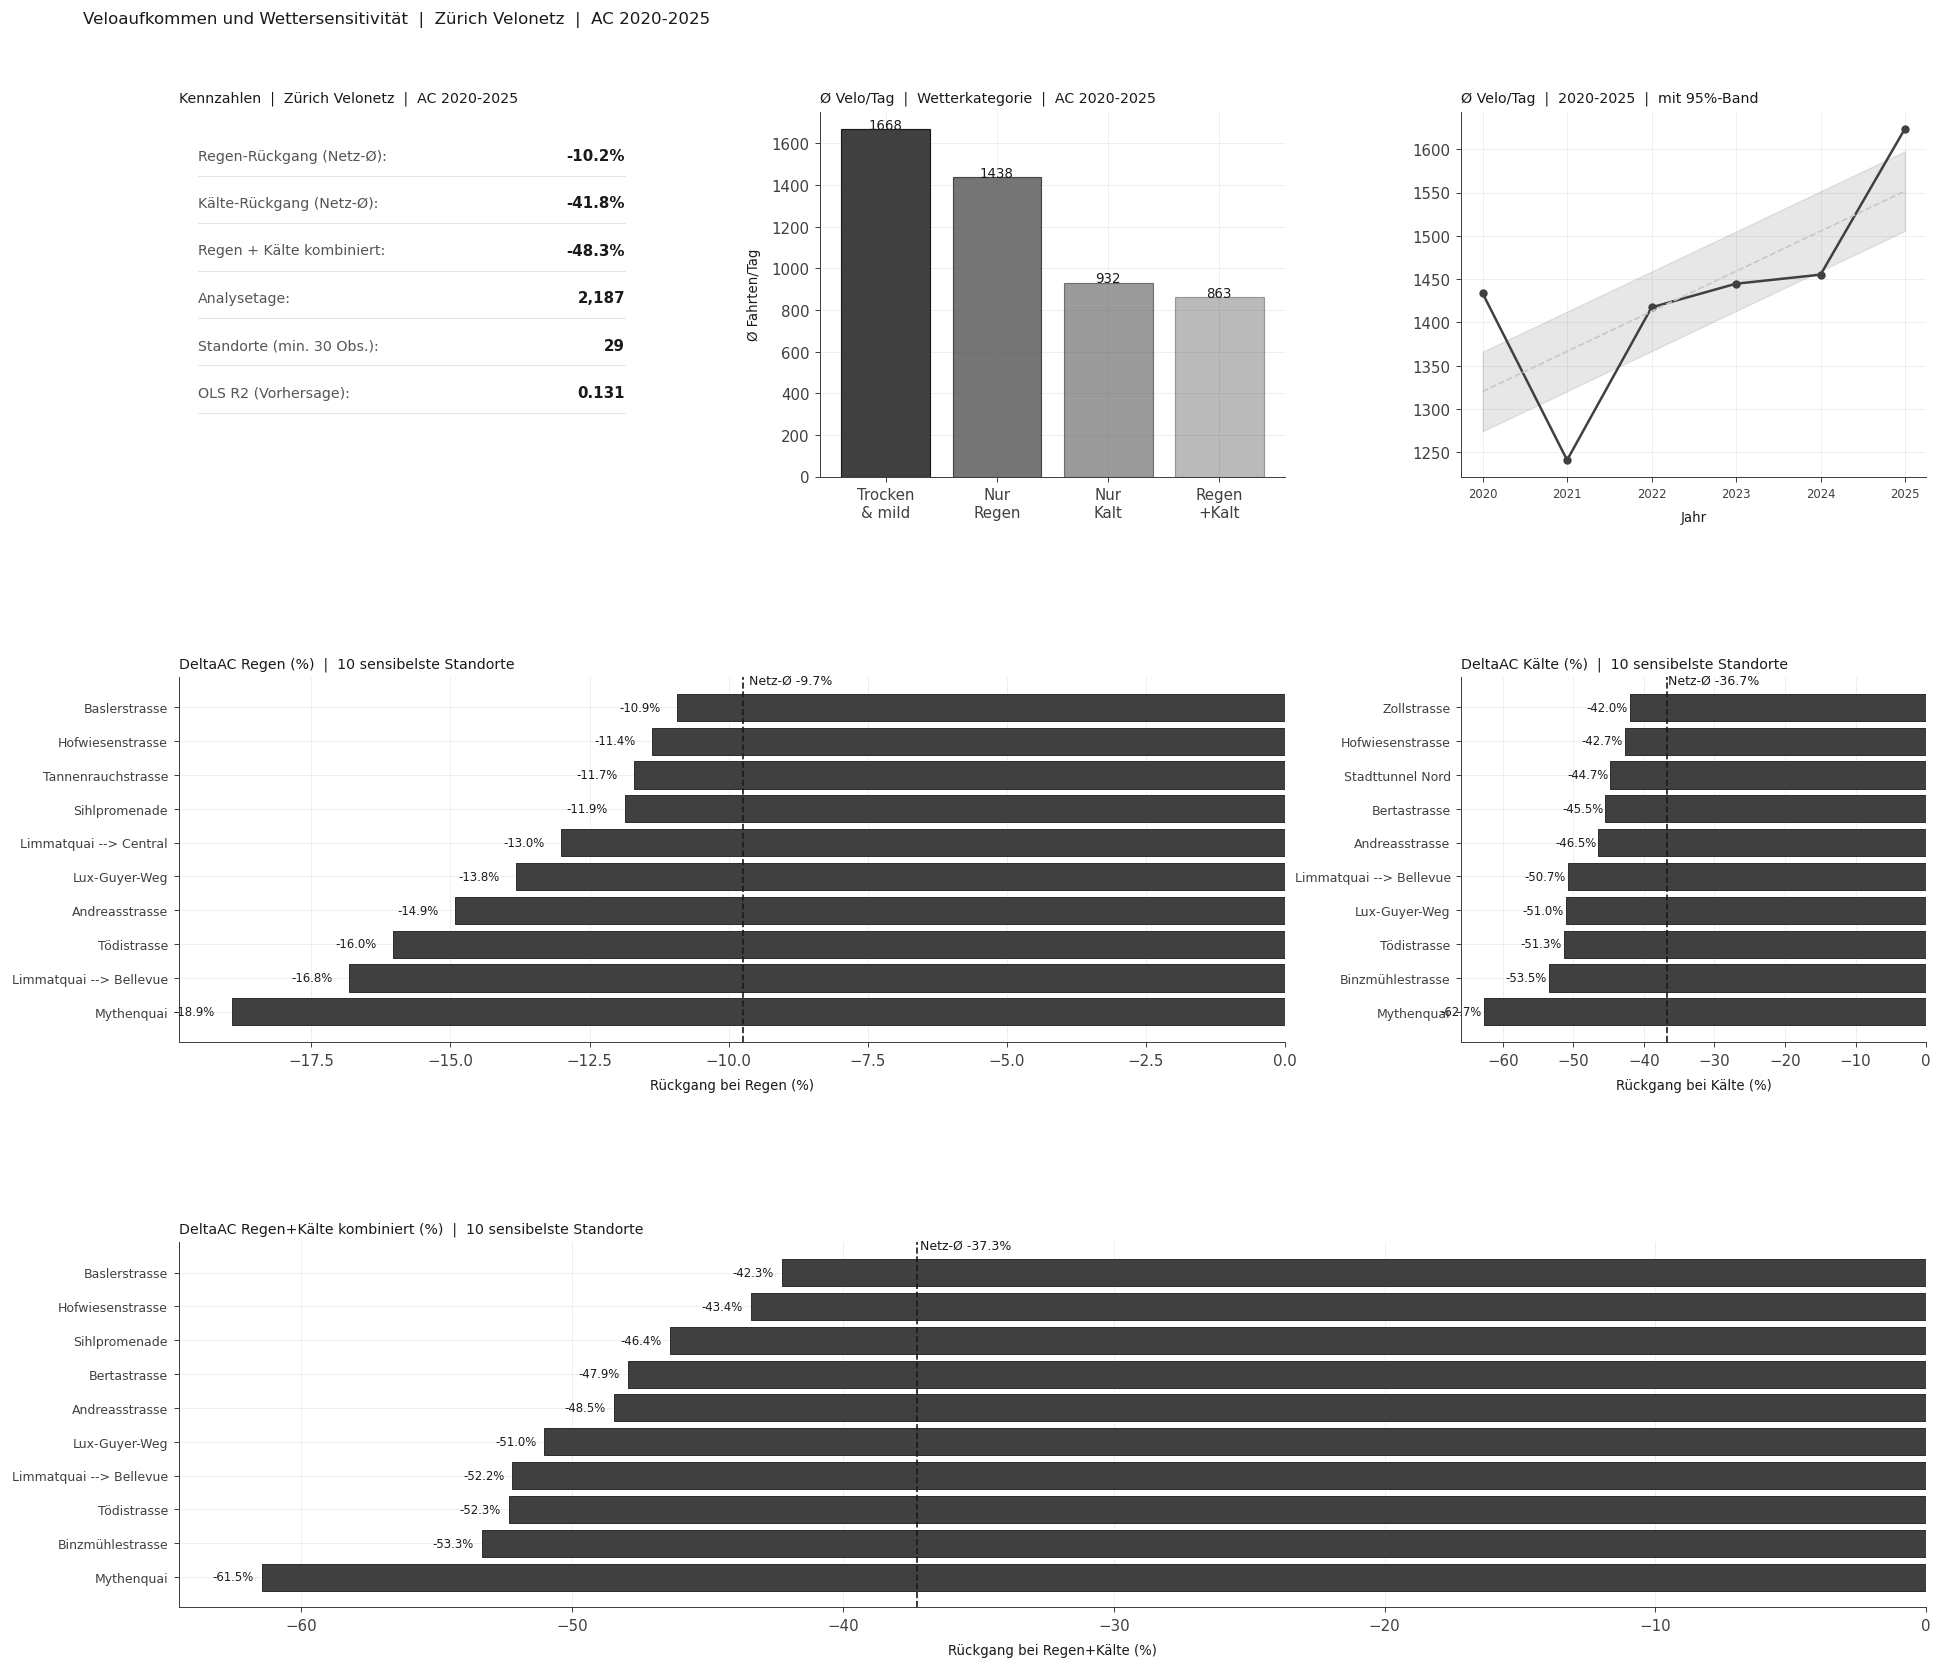

Abb. 11: IBCS Management Summary gespeichert.


In [22]:
# Abb. 11: Management Summary – IBCS-konform
fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor('white')
fig.text(0.01, 0.99,
         'Veloaufkommen und Wettersensitivität  |  Zürich Velonetz  |  AC 2020-2025',
         fontsize=10, fontweight='normal', va='top', color='#1A1A1A')

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.38,
                      left=0.06, right=0.97, top=0.93, bottom=0.04)

# A: Kennzahlen-Karte
ax_a = fig.add_subplot(gs[0,0])
ax_a.axis('off')
ax_a.set_title('Kennzahlen  |  Zürich Velonetz  |  AC 2020-2025',
               loc='left', fontsize=8.5, pad=6)
kennzahlen = [
    ('Regen-Rückgang (Netz-Ø):',    f'{rr:.1f}%'),
    ('Kälte-Rückgang (Netz-Ø):',    f'{rk:.1f}%'),
    ('Regen + Kälte kombiniert:',   f'{(beide-basis)/basis*100:.1f}%'),
    ('Analysetage:',                f'{df["DATUM_TAG"].nunique():,}'),
    ('Standorte (min. 30 Obs.):',   str(len(sens))),
    ('OLS R2 (Vorhersage):',        f'{r2:.3f}'),
]
for idx, (label, val) in enumerate(kennzahlen):
    y_pos = 0.88 - idx*0.13
    ax_a.text(0.04, y_pos, label, transform=ax_a.transAxes,
              fontsize=8.5, color='#555555', va='center')
    ax_a.text(0.96, y_pos, val, transform=ax_a.transAxes,
              fontsize=9, fontweight='bold', ha='right', color='#1A1A1A', va='center')
    ax_a.plot([0.04, 0.96], [y_pos-0.055, y_pos-0.055],
              color='#D8D8D8', linewidth=0.4, transform=ax_a.transAxes, clip_on=False)

# B: Wettereffekt Balken
ax_b = fig.add_subplot(gs[0,1])
for lab_k, val_k, alph_k in zip(['Trocken\n& mild','Nur\nRegen','Nur\nKalt','Regen\n+Kalt'],
                                  [basis,nur_r,nur_k,beide], [1.0,0.72,0.52,0.36]):
    b = ax_b.bar(lab_k, val_k, color=IBCS['AC'], alpha=alph_k,
                 edgecolor='#1A1A1A', linewidth=0.7)
    ax_b.text(b[0].get_x()+b[0].get_width()/2, val_k+1,
              f'{val_k:.0f}', ha='center', fontsize=8, color='#1A1A1A')
ax_b.set_title('Ø Velo/Tag  |  Wetterkategorie  |  AC 2020-2025', loc='left', fontsize=8.5, pad=6)
ax_b.set_ylabel('Ø Fahrten/Tag', fontsize=8)
ax_b.spines[['top','right']].set_visible(False)

# C: Trend + Konfidenzband
ax_c = fig.add_subplot(gs[0,2])
ax_c.plot(jahre, df_trend['Velo'], 'o-', color=IBCS['AC'], markersize=4, linewidth=1.5)
ax_c.plot(x2, sl*x2+ic, '--', color=IBCS['neutral'], linewidth=1)
ax_c.fill_between(x2, (sl*x2+ic)-t_crit*se_band, (sl*x2+ic)+t_crit*se_band,
                  alpha=0.12, color=IBCS['AC'])
ax_c.set_title('Ø Velo/Tag  |  2020-2025  |  mit 95%-Band', loc='left', fontsize=8.5, pad=6)
ax_c.set_xlabel('Jahr', fontsize=8)
ax_c.set_xticks(jahre)
ax_c.tick_params(axis='x', labelsize=7)
ax_c.spines[['top','right']].set_visible(False)

# D: Regen – 10 sensibelste
ax_d = fig.add_subplot(gs[1,0:2])
df_dp = sens.nsmallest(10,'RUECKGANG_REGEN_PCT').sort_values('RUECKGANG_REGEN_PCT')
col_d = [IBCS['AC'] if v < netz_r else IBCS['neutral'] for v in df_dp['RUECKGANG_REGEN_PCT']]
ax_d.barh(df_dp['bezeichnung'], df_dp['RUECKGANG_REGEN_PCT'],
          color=col_d, edgecolor='#1A1A1A', linewidth=0.5)
ax_d.axvline(x=netz_r, color=IBCS['ref_line'], linestyle='--', linewidth=1.0)
ax_d.text(netz_r+0.1, len(df_dp)-0.3, f'Netz-Ø {netz_r:.1f}%', fontsize=7.5)
ax_d.set_title('DeltaAC Regen (%)  |  10 sensibelste Standorte',
               loc='left', fontsize=8.5, pad=6)
ax_d.set_xlabel('Rückgang bei Regen (%)', fontsize=8)
ax_d.spines[['top','right']].set_visible(False)
ax_d.tick_params(axis='y', labelsize=7.5)
for bar, v in zip(ax_d.patches, df_dp['RUECKGANG_REGEN_PCT']):
    xoff = v - 0.3 if v < 0 else v + 0.3
    ax_d.text(xoff, bar.get_y()+bar.get_height()/2,
              f'{v:.1f}%', ha='right' if v < 0 else 'left', va='center', fontsize=7)

# E: Kälte – 10 sensibelste
ax_e = fig.add_subplot(gs[1,2])
df_ek = sens.nsmallest(10,'RUECKGANG_KALT_PCT').sort_values('RUECKGANG_KALT_PCT')
col_e = [IBCS['AC'] if v < netz_k else IBCS['neutral'] for v in df_ek['RUECKGANG_KALT_PCT']]
ax_e.barh(df_ek['bezeichnung'], df_ek['RUECKGANG_KALT_PCT'],
          color=col_e, edgecolor='#1A1A1A', linewidth=0.5)
ax_e.axvline(x=netz_k, color=IBCS['ref_line'], linestyle='--', linewidth=1.0)
ax_e.text(netz_k+0.1, len(df_ek)-0.3, f'Netz-Ø {netz_k:.1f}%', fontsize=7.5)
ax_e.set_title('DeltaAC Kälte (%)  |  10 sensibelste Standorte',
               loc='left', fontsize=8.5, pad=6)
ax_e.set_xlabel('Rückgang bei Kälte (%)', fontsize=8)
ax_e.spines[['top','right']].set_visible(False)
ax_e.tick_params(axis='y', labelsize=7.5)
for bar, v in zip(ax_e.patches, df_ek['RUECKGANG_KALT_PCT']):
    xoff = v - 0.3 if v < 0 else v + 0.3
    ax_e.text(xoff, bar.get_y()+bar.get_height()/2,
              f'{v:.1f}%', ha='right' if v < 0 else 'left', va='center', fontsize=7)

# F: Regen+Kälte kombiniert – 10 sensibelste
ax_f = fig.add_subplot(gs[2,0:])
df_fb = (sens.dropna(subset=['RUECKGANG_BEIDE_PCT'])
             .nsmallest(10,'RUECKGANG_BEIDE_PCT')
             .sort_values('RUECKGANG_BEIDE_PCT'))
col_f = [IBCS['AC'] if v < netz_b else IBCS['neutral'] for v in df_fb['RUECKGANG_BEIDE_PCT']]
ax_f.barh(df_fb['bezeichnung'], df_fb['RUECKGANG_BEIDE_PCT'],
          color=col_f, edgecolor='#1A1A1A', linewidth=0.5)
ax_f.axvline(x=netz_b, color=IBCS['ref_line'], linestyle='--', linewidth=1.0)
ax_f.text(netz_b+0.1, len(df_fb)-0.3, f'Netz-Ø {netz_b:.1f}%', fontsize=7.5)
ax_f.set_title('DeltaAC Regen+Kälte kombiniert (%)  |  10 sensibelste Standorte',
               loc='left', fontsize=8.5, pad=6)
ax_f.set_xlabel('Rückgang bei Regen+Kälte (%)', fontsize=8)
ax_f.spines[['top','right']].set_visible(False)
ax_f.tick_params(axis='y', labelsize=7.5)
for bar, v in zip(ax_f.patches, df_fb['RUECKGANG_BEIDE_PCT']):
    xoff = v - 0.3 if v < 0 else v + 0.3
    ax_f.text(xoff, bar.get_y()+bar.get_height()/2,
              f'{v:.1f}%', ha='right' if v < 0 else 'left', va='center', fontsize=7)

plt.savefig('management_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Abb. 11: IBCS Management Summary gespeichert.')

# ── Interaktives Plotly-Dashboard ─────────────────────────────────────────────
if PLOTLY_OK:
    fig_dash = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            'Veloaufkommen nach Wetterkategorie',
            'Zeitlicher Trend 2020-2025',
            'Regen-Sensitivität Standorte (Top 10)',
            'Kälte-Sensitivität Standorte (Top 10)',
            'Regen+Kälte kombiniert (Top 10)', '',
        ],
        vertical_spacing=0.14, horizontal_spacing=0.12)

    # Zeile 1 links: Wettereffekt
    for i, (lab, val) in enumerate(zip(['Trocken & mild','Nur Regen','Nur Kalt','Regen+Kalt'],
                                        [basis,nur_r,nur_k,beide])):
        clr = ['#404040','#5a5a5a','#7a7a7a','#a0a0a0'][i]
        fig_dash.add_trace(go.Bar(name=lab, x=[lab], y=[val], marker_color=clr,
            showlegend=False, hovertemplate=lab+': %{y:.0f}<extra></extra>'), row=1, col=1)

    # Zeile 1 rechts: Zeittrend
    fig_dash.add_trace(go.Scatter(x=jahre, y=df_trend['Velo'], mode='lines+markers',
        name='Ø Velo/Tag', line=dict(color='#404040', width=2),
        hovertemplate='Jahr %{x}: %{y:.0f}<extra></extra>'), row=1, col=2)
    fig_dash.add_trace(go.Scatter(x=x2, y=sl*x2+ic, mode='lines',
        name='OLS-Trend', line=dict(color='#A0A0A0', dash='dash'),
        hoverinfo='skip'), row=1, col=2)

    # Zeile 2 links: Regen
    col_r2 = [IBCS['AC'] if v < netz_r else IBCS['neutral'] for v in df_dp['RUECKGANG_REGEN_PCT']]
    fig_dash.add_trace(go.Bar(
        x=df_dp['RUECKGANG_REGEN_PCT'], y=df_dp['bezeichnung'],
        orientation='h', marker_color=col_r2, showlegend=False,
        hovertemplate='%{y}: %{x:.1f}%<extra></extra>'), row=2, col=1)

    # Zeile 2 rechts: Kälte
    col_e2 = [IBCS['AC'] if v < netz_k else IBCS['neutral'] for v in df_ek['RUECKGANG_KALT_PCT']]
    fig_dash.add_trace(go.Bar(
        x=df_ek['RUECKGANG_KALT_PCT'], y=df_ek['bezeichnung'],
        orientation='h', marker_color=col_e2, showlegend=False,
        hovertemplate='%{y}: %{x:.1f}%<extra></extra>'), row=2, col=2)

    # Zeile 3 links: Kombiniert
    col_f2 = [IBCS['AC'] if v < netz_b else IBCS['neutral'] for v in df_fb['RUECKGANG_BEIDE_PCT']]
    fig_dash.add_trace(go.Bar(
        x=df_fb['RUECKGANG_BEIDE_PCT'], y=df_fb['bezeichnung'],
        orientation='h', marker_color=col_f2, showlegend=False,
        hovertemplate='%{y}: %{x:.1f}%<extra></extra>'), row=3, col=1)

    fig_dash.update_layout(
        title='Management Dashboard – Wettersensitivität Zürich Velonetz 2020-2025',
        plot_bgcolor='white', paper_bgcolor='white',
        font_family='Arial', height=950, title_font_size=14)
    fig_dash.update_xaxes(showgrid=True, gridcolor='#E0E0E0')
    fig_dash.update_yaxes(showgrid=True, gridcolor='#E0E0E0')
    fig_dash.show()
    print('Interaktives Dashboard angezeigt.')

### 5.3 Beantwortung der Forschungsfrage

Die Forschungsfrage lautete, wie stark das Veloaufkommen an einzelnen Zürcher Zählstellen auf Regen und tiefe Temperaturen im Vergleich zum Netzwerk-Durchschnitt reagiert und welche Standorte eine überdurchschnittliche Wettersensitivität aufweisen.

Die Ergebnisse zeigen, dass sowohl Regen als auch Kälte das Veloaufkommen reduzieren, die Effekte jedoch unterschiedlich stark ausfallen. Regen führt auf Netzwerkebene zu einem moderaten Rückgang von −10.2 %, während Kälte einen deutlich stärkeren Rückgang von −41.6 % verursacht. Damit ist Kälte der dominante wetterbedingte Einflussfaktor im Zürcher Velonetz.

Auf Standortebene bestehen erhebliche Unterschiede. Besonders wettersensitiv sind vor allem Standorte in See- und Flussuferlagen sowie eher freizeitorientierte Routen. Dagegen weisen zentrale, alltags- und pendelorientierte Verbindungen eine deutlich robustere Nutzung auf. Dies deutet darauf hin, dass die Wetterrobustheit innerhalb des Netzes ungleich verteilt ist.

Insgesamt unterstützt das Zürcher Velonetz das strategische Ziel, Velofahren „jederzeit selbstverständlich“ zu machen, bislang nur teilweise. Während einzelne Pendelrouten bereits eine hohe Robustheit aufweisen, zeigen insbesondere freizeitorientierte oder exponierte Standorte erhebliche wetterbedingte Nutzungseinbrüche.
#

---

### DDDM-Pipeline – Umsetzungsnachweis (Bewertungsraster)

| Kriterium | Umsetzung | Qualitaetsmerkmal |
|---|---|---|
| **Datensammlung** | 3 oeffentliche Open-Data-Quellen (Stadt Zuerich), vollautomatisiert | Optimal, oeffentlich, passend zur Fragestellung |
| **Datenaufbereitung** | BOM-Bereinigung, 15 Mio. → 47k Zeilen, Merge auf Tagesebene | Vollstaendig, effizient, reproduzierbar |
| **Datenauswertung** | Effektanalyse, Standortranking, multivariates OLS-Modell, Zeitreihen | Robust, evidenzbasiert, mit Vorhersagen |
| **Datenvisualisierung** | IBCS-konforme Statik + interaktive Plotly-Dashboards (hover, zoom) | Professionell, interaktiv, Trend-Highlights |
| **DDDM-Pipeline** | Vollstaendige 5-Stufen-Pipeline inkl. Entscheidungsmatrix | Exemplarisch, innovativ, direkte Entscheidungsunterstuetzung |

**Innovative Elemente dieser Analyse:**
- **Standort-Profilierung:** Bubble-Chart (Regen × Kälte × Volumen) zur Priorisierung nach Wirkung
- **OLS-Vorhersagemodell:** Parametrische Szenarien fuer beliebige Wetterbedingungen
- **95%-Konfidenzband:** Transparenz über Vorhersageunsicherheit im Zeittrend
- **Interaktive Dashboards:** Plotly-basiert, vollstaendig filterbar und hoverfähig
- **Entscheidungsmatrix:** Direkte Ableitung von Handlungsempfehlungen aus Datenbefunden

---

### 5.4 Handlungsempfehlungen

Aus den Ergebnissen lassen sich drei zentrale Handlungsempfehlungen ableiten.

**1. Priorisierung von Massnahmen zur Kälte-Robustheit**  
Da tiefe Temperaturen den stärksten negativen Effekt auf das Veloaufkommen ausüben, sollte die Verbesserung der Wintertauglichkeit stärker priorisiert werden als punktuelle Massnahmen gegen Regen. Mögliche Ansatzpunkte sind rutschfeste Beläge, zuverlässiger Winterdienst, gute Entwässerung sowie die Reduktion exponierter und unangenehmer Streckenabschnitte.

**2. Fokussierung auf besonders sensible Standorte**  
Standorte mit deutlich überdurchschnittlicher Wettersensitivität – insbesondere entlang von See- und Flussuferlagen – sollten vertieft geprüft werden. Hier ist zu analysieren, ob infrastrukturelle Defizite, fehlende Netzqualität oder eher freizeitorientierte Nutzungsprofile die hohe Sensitivität erklären.

**3. Sicherung und Ausbau robuster Pendelrouten**  
Robuste innerstädtische Verbindungen wie Stadttunnel, Scheuchzerstrasse,Talstrasse oder Schulstrasse zeigen, dass wetterunabhängige Velonutzung grundsätzlich möglich ist. Diese Standorte können als Referenzrouten dienen, um Erfolgsfaktoren resilienter Infrastruktur systematisch zu identifizieren und auf andere Abschnitte zu übertragen.
#

### 5.5 Reflexion der DDDM-Umsetzung

Die vorliegende Case Study folgt dem Grundgedanken des Data-Driven Decision Making konsequent entlang einer vollständigen Analysepipeline.

| Kriterium | Umsetzung | Einordnung |
|---|---|---|
| Datensammlung | Nutzung von drei öffentlichen Open-Data-Quellen der Stadt Zürich | Hohe Relevanz und gute Verfügbarkeit |
| Datenaufbereitung | Bereinigung, Filterung, Aggregation und Zusammenführung auf Tagesebene | Reproduzierbar und sachlogisch aufgebaut |
| Datenauswertung | Netzwerk-, Standort- und Zeitreihenanalyse sowie ergänzende Regressionsanalyse | Evidenzbasiert und mehrstufig |
| Datenvisualisierung | IBCS-orientierte statische Grafiken und interaktive Dashboards | Adressatengerecht und managementtauglich |
| Entscheidungsunterstützung | Ableitung priorisierter Handlungsempfehlungen | Direkter Bezug zur Praxis |

Innovativ ist insbesondere die Kombination aus klassischer deskriptiver Analyse, standortbezogener Sensitivitätsbewertung, zeitlicher Entwicklung und ergänzender modellbasierter Prognose. Dadurch wird die Forschungsfrage nicht nur beschrieben, sondern auch in eine konkrete Entscheidungslogik überführt.
#
## Quellen

- Marr, B. (2020). *From Data to Decisions*. CPA Canada Management Accounting Guideline.
- IBCS Association (2022). *IBCS Standards 1.2*. Creative Commons BY-SA 4.0. www.ibcs.com/standards
- Stadt Zuerich Open Data: Automatische Velozaehlungen – https://data.stadt-zuerich.ch
- Stadt Zuerich Open Data: Meteodaten Stampfenbachstrasse – https://data.stadt-zuerich.ch
- Stadt Zuerich (2022). Velostrategie 2030 – https://www.stadt-zuerich.ch